# BuildSafe-AI · Notebook 07 — Model Optimization, Final Model Selection & Backend Export
**IT3051 Fundamentals of Data Mining · Mini Project 2026 · Assignment Stage 7 (feeds Stage 9 Backend)**

Notebook 06 compared five algorithms with default settings. This notebook **improves them, picks one final model with a rule written down in advance, and exports it** so the backend can load it.

| Assignment requirement (Stage 7 / 9) | Where it is covered |
|---|---|
| Hyper-parameter tuning for suitable models | §2 — every algorithm family is tuned |
| An appropriate optimisation / search strategy | §2 — random search on the *same* leakage-safe time-series folds, scored by Macro-F1; boosting tree-count tuned by staged evaluation |
| Does feature selection / engineering / other modelling choices help? | §4 chi² feature count `k` · §5 feature-group ablation (incl. the engineered building-history features) · §6 class-weight strength |
| Compare tuned models with baselines | §3 — tuned vs baseline, per fold and on average |
| Select the final model and justify it | §7 — **pre-declared selection rule**, decision trail, §8 locked-test evaluation, error analysis |
| Final system must use the final model **and** the right preprocessing pipeline | §9 — one saved scikit-learn `Pipeline` (preprocessing + model), model card, train/serve consistency test, reference `predict_records()` |

**Run order:** Notebook 02 → 06 → **07 (this)**. It re-uses the baseline results saved by Notebook 06 (`results/stage6_baseline_folds.json`) and recomputes them only if that file is missing.
**Runtime:** budget-dependent — about 1–3 h on a laptop with the default budgets in §2 (more trials = better search, longer wait). `QUICK_RUN = True` gives a ~5 min smoke test (not real results).

### Discipline used throughout
1. **Tuning data = training period only** (time-ordered CV folds, preprocessing re-fitted inside each fold).
2. **The test set is not touched until §8**, after the final model is chosen. It is evaluated once and nothing is changed afterwards.
3. The selection rule (§7) is written **before** the candidates are scored, so it cannot be bent to fit the answer.

**Layout:** each of the five models has **its own cells** — definition (§0), baseline loading (§0), search space (§1) and random search (§2) — so you can change the search space or re-run the search of one model without touching the others. Comparison, selection and export then collect all five.

## 0. Setup and data

In [1]:
import os, re, sys, json, time, gc, platform, warnings
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib
from scipy import sparse
from scipy.stats import loguniform

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import TimeSeriesSplit, ParameterSampler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (precision_recall_fscore_support, confusion_matrix, roc_auc_score,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

try:
    import lightgbm as lgb
    import xgboost as xgb
except ImportError as e:
    raise ImportError("Install the boosting libraries first:   pip install lightgbm xgboost") from e

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", rc={"axes.titleweight": "bold"})
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

# ---------------------------------------------------------------- run switches
RANDOM_STATE = 42          # same seed as Notebook 02, so every number is reproducible
QUICK_RUN = False          # True = tiny smoke test (small sample, few trials) -> checks the notebook runs end-to-end.
                           # Keep False to produce the real results for the report.
QUICK_RUN = QUICK_RUN or os.environ.get("BUILDSAFE_QUICK") == "1"
N_SPLITS = 3               # time-series CV folds (expanding window)

# ---------------------------------------------------------------- project paths (works from notebooks/ or notebooks/Models/)
def find_project_root():
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "artifacts" / "preprocessing_config.json").exists():
            return p
    raise FileNotFoundError("Could not find artifacts/preprocessing_config.json above the current folder. "
                            "Open this notebook from inside the BuildSafe-AI project (Notebook 02 must have been run).")

ROOT = find_project_root()
ART, MODELS, RESULTS = ROOT / "artifacts", ROOT / "models", ROOT / "results"
if QUICK_RUN:                       # a smoke test must never overwrite real results or the real exported model
    MODELS, RESULTS = MODELS / "quick_run", RESULTS / "quick_run"
FIG = RESULTS / "figures"
for d in (MODELS, RESULTS, FIG):
    d.mkdir(parents=True, exist_ok=True)

print("Project root :", ROOT)
print("QUICK_RUN    :", QUICK_RUN, "(smoke test - numbers are NOT final results)" if QUICK_RUN else "(full run)")
print("Versions     : python", platform.python_version(), "| numpy", np.__version__, "| pandas", pd.__version__,
      "| lightgbm", lgb.__version__, "| xgboost", xgb.__version__)
import sklearn; print("               scikit-learn", sklearn.__version__)

Project root : D:\FDM Pro\BuildSafe-AI
QUICK_RUN    : False (full run)
Versions     : python 3.13.7 | numpy 2.5.2 | pandas 3.0.5 | lightgbm 4.7.0 | xgboost 3.4.1
               scikit-learn 1.9.1


In [2]:
cfg = json.load(open(ART / "preprocessing_config.json", encoding="utf-8"))
FEATURES, TEXT_COL = cfg["features"], cfg["text_col"]
CAT_COLS, BIN_COLS, NUM_COLS = cfg["cat_cols"], cfg["bin_cols"], cfg["num_cols"]
TARGET = "SEVERITY"
CLASS_NAMES = ["CLASS - 1", "CLASS - 2", "CLASS - 3"]
CLASS_MEANING = {"CLASS - 1": "Immediately hazardous", "CLASS - 2": "Major", "CLASS - 3": "Lesser"}
LABEL2ID = {c: i for i, c in enumerate(CLASS_NAMES)}
SHORT = ["Class 1", "Class 2", "Class 3"]

def load_table(name):
    df = pd.read_csv(ART / name, parse_dates=["ISSUE_DATE"])
    df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str)      # 6-18 rows have no description -> empty text
    df[CAT_COLS] = df[CAT_COLS].astype(str)                 # the saved encoder was fitted on STRING categories
    return df

train_df, test_df = load_table("train_engineered.csv"), load_table("test_engineered.csv")
y_train = train_df[TARGET].map(LABEL2ID).to_numpy()
y_test = test_df[TARGET].map(LABEL2ID).to_numpy()

# stored matrices from Notebook 02 (full training set; used for the final fits)
STORED = {
    "linear": (sparse.load_npz(ART / "X_train_linear.npz").tocsr().astype(np.float32),
               sparse.load_npz(ART / "X_test_linear.npz").tocsr().astype(np.float32)),
    "tree":   (sparse.load_npz(ART / "X_train_tree.npz").tocsr().astype(np.float32),
               sparse.load_npz(ART / "X_test_tree.npz").tocsr().astype(np.float32)),
}
names_linear = pd.read_csv(ART / "feature_names_linear.csv")["feature"].astype(str).to_numpy()
names_tree = pd.read_csv(ART / "feature_names_tree.csv")["feature"].astype(str).to_numpy()

# ---- consistency checks between the CSV tables and the stored matrices
assert train_df["ISSUE_DATE"].is_monotonic_increasing, "train_engineered.csv must be sorted by date"
assert (pd.read_csv(ART / "y_train.csv").squeeze().map(LABEL2ID).to_numpy() == y_train).all(), "y_train.csv does not match train_engineered.csv"
assert (pd.read_csv(ART / "y_test.csv").squeeze().map(LABEL2ID).to_numpy() == y_test).all(), "y_test.csv does not match test_engineered.csv"
for v in ("linear", "tree"):
    assert STORED[v][0].shape[0] == len(train_df) and STORED[v][1].shape[0] == len(test_df)
assert STORED["linear"][0].shape[1] == len(names_linear) and STORED["tree"][0].shape[1] == len(names_tree)

if QUICK_RUN:   # smoke test: keep the NEWEST 12,000 training rows and the OLDEST 4,000 test rows (time order preserved)
    NQ_TR, NQ_TE = 12000, 4000
    train_df, test_df = train_df.iloc[-NQ_TR:].reset_index(drop=True), test_df.iloc[:NQ_TE].reset_index(drop=True)
    y_train, y_test = y_train[-NQ_TR:], y_test[:NQ_TE]
    STORED = {v: (a[-NQ_TR:], b[:NQ_TE]) for v, (a, b) in STORED.items()}

print(f"train {train_df.shape}  {train_df.ISSUE_DATE.min().date()} -> {train_df.ISSUE_DATE.max().date()}")
print(f"test  {test_df.shape}  {test_df.ISSUE_DATE.min().date()} -> {test_df.ISSUE_DATE.max().date()}")
print("stored matrices  linear:", STORED["linear"][0].shape, "| tree:", STORED["tree"][0].shape)

train (81780, 17)  2025-01-01 -> 2026-05-12
test  (20554, 17)  2026-05-13 -> 2026-09-10
stored matrices  linear: (81780, 40072) | tree: (81780, 5000)


In [3]:
def macro_ovr_auc(y, S):
    """Macro one-vs-rest ROC-AUC from any score matrix (probabilities OR SVM margins)."""
    aucs = []
    for c in range(3):
        yb = (y == c).astype(int)
        if 0 < yb.sum() < len(yb):
            aucs.append(roc_auc_score(yb, S[:, c]))
    return float(np.mean(aucs))

def evaluate(y, pred, S=None):
    """One dictionary of all metrics used in this project (class ids: 0 = Class 1, 1 = Class 2, 2 = Class 3)."""
    p, r, f, _ = precision_recall_fscore_support(y, pred, labels=[0, 1, 2], zero_division=0)
    cm = confusion_matrix(y, pred, labels=[0, 1, 2])
    out = dict(macro_f1=f.mean(), accuracy=float((pred == y).mean()), balanced_accuracy=r.mean(),
               c1_recall=r[0], c1_precision=p[0], c1_f1=f[0], c2_f1=f[1],
               c3_recall=r[2], c3_precision=p[2], c3_f1=f[2],
               c1_as_c3=cm[0, 2] / max(cm[0].sum(), 1))          # most dangerous error: hazardous -> lesser
    if S is not None:
        out["macro_auc_ovr"] = macro_ovr_auc(y, S)
    return {k: float(v) for k, v in out.items()}

METRIC_COLS = ["macro_f1", "accuracy", "c1_recall", "c1_precision", "c3_recall", "c3_f1", "macro_auc_ovr"]
METRIC_LABELS = {"macro_f1": "Macro-F1", "accuracy": "Accuracy", "c1_recall": "Class-1 recall", "c1_precision": "Class-1 precision",
                 "c3_recall": "Class-3 recall", "c3_f1": "Class-3 F1", "macro_auc_ovr": "Macro AUC (OvR)",
                 "balanced_accuracy": "Balanced acc.", "c1_as_c3": "Class-1 -> Class-3 rate", "c1_f1": "Class-1 F1", "c2_f1": "Class-2 F1"}

In [4]:
def make_features():
    """The SAME ColumnTransformer recipe as Notebook 02 (TF-IDF + one-hot + passthrough + log1p/MinMax).
    Built from code (not cloned from the .joblib) so it can be re-fitted inside every CV fold on any scikit-learn version."""
    log_minmax = Pipeline([("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                           ("scale", MinMaxScaler(clip=True))])
    return ColumnTransformer([
        ("text", TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.9, sublinear_tf=True, max_features=40000,
                                 lowercase=False, token_pattern=r"(?u)\b[A-Z]{2,}\b|\b\d+-\d+(?:\.\d+)*\b"), TEXT_COL),
        ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=50, sparse_output=True), CAT_COLS),
        ("bin", "passthrough", BIN_COLS),
        ("num", log_minmax, NUM_COLS)], sparse_threshold=1.0, verbose_feature_names_out=True)

def top_k_columns(scores, k):
    """Columns kept by SelectKBest(chi2, k) - same rule as scikit-learn (stable sort, NaN = worst), returned in column order."""
    s = np.nan_to_num(scores, nan=np.finfo(np.float64).min)
    return np.sort(np.argsort(s, kind="mergesort")[-k:])

def build_cv_folds(df, y, n_splits=N_SPLITS):
    """Expanding-window time-series folds. Inside EVERY fold the whole preprocessing (TF-IDF vocabulary + IDF, one-hot
    categories, MinMax ranges, chi2 scores) is fitted on that fold's TRAINING rows only and then applied to its validation rows."""
    folds = []
    for fi, (tr, va) in enumerate(TimeSeriesSplit(n_splits=n_splits).split(df)):
        t0 = time.time()
        feats = make_features()
        Xtr = feats.fit_transform(df.iloc[tr][FEATURES], y[tr]).tocsr().astype(np.float32)
        Xva = feats.transform(df.iloc[va][FEATURES]).tocsr().astype(np.float32)
        scores = chi2(Xtr, y[tr])[0]
        folds.append(dict(i=fi, tr_idx=tr, va_idx=va, y_tr=y[tr], y_va=y[va], Xtr=Xtr, Xva=Xva,
                          scores=scores, names=np.asarray(feats.get_feature_names_out()), cache={}))
        print(f"fold {fi + 1}/{n_splits}: train {len(tr):>6,} | validation {len(va):>6,} | {Xtr.shape[1]:,} features | {time.time() - t0:.0f}s")
    return folds

def fold_matrices(f, view, k=None, drop=None):
    """Matrices of one fold for a model 'view'. linear view = all features, tree view = top-k chi2 features (k default 5000).
    `drop` = list of name fragments to remove (used by the feature-group ablation)."""
    key = (view, k, tuple(drop or ()))
    if key in f["cache"]:
        return f["cache"][key]
    n_all = f["Xtr"].shape[1]
    cols = np.arange(n_all) if k is None or k >= n_all else top_k_columns(f["scores"], k)
    if drop:
        pat = "|".join(re.escape(d) for d in drop)
        cols = cols[~pd.Series(f["names"][cols]).str.contains(pat).to_numpy()]
    out = (f["Xtr"], f["Xva"]) if len(cols) == n_all else (f["Xtr"][:, cols], f["Xva"][:, cols])
    if len(f["cache"]) >= 6:                       # keep memory bounded
        f["cache"].pop(next(iter(f["cache"])))
    f["cache"][key] = out
    return out

### Model definitions
Each model is defined in **its own cell** (4.1–4.5) and plugged into one shared evaluation engine (4.6) — identical to Notebook 06.

In [5]:
MODEL_NAMES = ["Logistic Regression", "Linear SVM", "Random Forest", "LightGBM", "XGBoost"]

# Every model fills in its OWN entry of these four dictionaries in its own cell below (4.1 ... 4.5):
VIEW     = {}   # which input matrix the model gets: "linear" = scaled sparse matrix, ALL features | "tree" = top-k chi2 features
BASELINE = {}   # baseline settings = sensible defaults, decided BEFORE looking at any result.
                # 'k' = number of chi2-selected features (tree view only), 'alpha' = strength of class balancing (1.0 = fully 'balanced', 0 = none)
BUILDERS = {}   # function that creates the unfitted model (+ extra fit kwargs)
SCORERS  = {}   # function that returns class scores (probabilities; margins for the SVM)

def class_weight_dict(y, alpha=1.0):
    """'balanced' weights (n / (3 * count)) raised to the power alpha, computed from the TRAINING labels passed in."""
    w = compute_class_weight("balanced", classes=np.array([0, 1, 2]), y=y)
    return {i: float(w[i] ** alpha) for i in range(3)}

def clean_params(p):
    """numpy scalars -> plain python (for JSON / printing)."""
    return {k: (v.item() if isinstance(v, np.generic) else v) for k, v in p.items()}

### 4.1 Logistic Regression
Linear, probabilistic. Gets **all** ≈ 40 k scaled features. Coefficients are directly interpretable (§7). `alpha` = class-weight strength, `C` = inverse regularisation strength.

In [6]:
# =============================== MODEL 1 / 5 : LOGISTIC REGRESSION ===============================
VIEW["Logistic Regression"] = "linear"
BASELINE["Logistic Regression"] = dict(C=1.0, max_iter=300, alpha=1.0)

def build_logistic_regression(p, cw, y_fit):
    """Returns (unfitted model, extra fit kwargs). `cw` = class-weight dict computed from the training rows only."""
    return LogisticRegression(C=p["C"], class_weight=cw, solver="lbfgs", max_iter=p["max_iter"]), {}

def score_logistic_regression(model, X, n_iter=None):
    return model.predict_proba(X)

BUILDERS["Logistic Regression"], SCORERS["Logistic Regression"] = build_logistic_regression, score_logistic_regression
print("Logistic Regression  | input:", VIEW["Logistic Regression"], "| baseline:", BASELINE["Logistic Regression"])

Logistic Regression  | input: linear | baseline: {'C': 1.0, 'max_iter': 300, 'alpha': 1.0}


### 4.2 Linear SVM (`LinearSVC`)
Linear, max-margin; usually the strongest linear learner on sparse text and very fast. It has **no probabilities** (margins only), so it is reported but cannot be the deployed model in Notebook 07.

In [7]:
# =============================== MODEL 2 / 5 : LINEAR SVM ===============================
VIEW["Linear SVM"] = "linear"
BASELINE["Linear SVM"] = dict(C=1.0, alpha=1.0)

def build_linear_svm(p, cw, y_fit):
    return LinearSVC(C=p["C"], class_weight=cw, max_iter=5000, random_state=RANDOM_STATE), {}

def score_linear_svm(model, X, n_iter=None):
    return model.decision_function(X)            # margins, not probabilities

BUILDERS["Linear SVM"], SCORERS["Linear SVM"] = build_linear_svm, score_linear_svm
print("Linear SVM           | input:", VIEW["Linear SVM"], "| baseline:", BASELINE["Linear SVM"])

Linear SVM           | input: linear | baseline: {'C': 1.0, 'alpha': 1.0}


### 4.3 Random Forest
Bagged trees; non-linear, combines text with context (violation type, building history). Gets the **top-5 000 chi²** features.

In [8]:
# =============================== MODEL 3 / 5 : RANDOM FOREST ===============================
VIEW["Random Forest"] = "tree"
BASELINE["Random Forest"] = dict(n_estimators=40 if QUICK_RUN else 200,      # QUICK_RUN: fewer trees so the smoke test is fast
                                 max_depth=None, min_samples_leaf=1, max_features="sqrt", k=5000, alpha=1.0)

def build_random_forest(p, cw, y_fit):
    return RandomForestClassifier(n_estimators=p["n_estimators"], max_depth=p["max_depth"], min_samples_leaf=p["min_samples_leaf"],
                                  max_features=p["max_features"], class_weight=cw, n_jobs=-1, random_state=RANDOM_STATE), {}

def score_random_forest(model, X, n_iter=None):
    return model.predict_proba(X)

BUILDERS["Random Forest"], SCORERS["Random Forest"] = build_random_forest, score_random_forest
print("Random Forest        | input:", VIEW["Random Forest"], "| baseline:", BASELINE["Random Forest"])

Random Forest        | input: tree | baseline: {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'k': 5000, 'alpha': 1.0}


### 4.4 LightGBM
Gradient-boosted trees (leaf-wise growth); efficient on sparse input and learns interactions sequentially. Gets the **top-5 000 chi²** features. Boosting libraries take **per-row sample weights** instead of a `class_weight` dict.

In [9]:
# =============================== MODEL 4 / 5 : LIGHTGBM ===============================
VIEW["LightGBM"] = "tree"
BASELINE["LightGBM"] = dict(n_estimators=60 if QUICK_RUN else 300,           # QUICK_RUN: fewer trees so the smoke test is fast
                            learning_rate=0.1, num_leaves=31, min_child_samples=20,
                            colsample_bytree=1.0, subsample=1.0, reg_lambda=0.0, k=5000, alpha=1.0)

def build_lightgbm(p, cw, y_fit):
    sw = np.asarray([cw[0], cw[1], cw[2]])[y_fit]                      # per-row sample weights from the class weights
    m = lgb.LGBMClassifier(objective="multiclass", n_estimators=p["n_estimators"], learning_rate=p["learning_rate"],
                           num_leaves=p["num_leaves"], min_child_samples=p["min_child_samples"], colsample_bytree=p["colsample_bytree"],
                           subsample=p["subsample"], subsample_freq=1, reg_lambda=p["reg_lambda"],
                           random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    return m, {"sample_weight": sw}

def score_lightgbm(model, X, n_iter=None):
    """n_iter = use only the first n_iter trees (staged evaluation used by the tuning in Notebook 07)."""
    return model.predict_proba(X, num_iteration=n_iter) if n_iter else model.predict_proba(X)

BUILDERS["LightGBM"], SCORERS["LightGBM"] = build_lightgbm, score_lightgbm
print("LightGBM             | input:", VIEW["LightGBM"], "| baseline:", BASELINE["LightGBM"])

LightGBM             | input: tree | baseline: {'n_estimators': 300, 'learning_rate': 0.1, 'num_leaves': 31, 'min_child_samples': 20, 'colsample_bytree': 1.0, 'subsample': 1.0, 'reg_lambda': 0.0, 'k': 5000, 'alpha': 1.0}


### 4.5 XGBoost
Second boosting implementation (level-wise growth) — shows whether the *library* matters or only the *method*. Gets the **top-5 000 chi²** features.

In [10]:
# =============================== MODEL 5 / 5 : XGBOOST ===============================
VIEW["XGBoost"] = "tree"
BASELINE["XGBoost"] = dict(n_estimators=40 if QUICK_RUN else 300,            # QUICK_RUN: fewer trees so the smoke test is fast
                           learning_rate=0.1, max_depth=6, min_child_weight=1,
                           subsample=0.8, colsample_bytree=0.5, reg_lambda=1.0, k=5000, alpha=1.0)

def build_xgboost(p, cw, y_fit):
    sw = np.asarray([cw[0], cw[1], cw[2]])[y_fit]                      # per-row sample weights from the class weights
    m = xgb.XGBClassifier(objective="multi:softprob", n_estimators=p["n_estimators"], learning_rate=p["learning_rate"],
                          max_depth=p["max_depth"], min_child_weight=p["min_child_weight"], subsample=p["subsample"],
                          colsample_bytree=p["colsample_bytree"], reg_lambda=p["reg_lambda"], tree_method="hist",
                          eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    return m, {"sample_weight": sw}

def score_xgboost(model, X, n_iter=None):
    """n_iter = use only the first n_iter trees (staged evaluation used by the tuning in Notebook 07)."""
    return model.predict_proba(X, iteration_range=(0, n_iter)) if n_iter else model.predict_proba(X)

BUILDERS["XGBoost"], SCORERS["XGBoost"] = build_xgboost, score_xgboost
print("XGBoost              | input:", VIEW["XGBoost"], "| baseline:", BASELINE["XGBoost"])

XGBoost              | input: tree | baseline: {'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 1, 'subsample': 0.8, 'colsample_bytree': 0.5, 'reg_lambda': 1.0, 'k': 5000, 'alpha': 1.0}


### 4.6 Shared evaluation engine
The five models above are plugged into **one** cross-validation engine, so every model is trained, scored and logged by exactly the same code — differences between the models therefore come from the algorithm, not from the way it was tested.

In [11]:
missing = [n for n in MODEL_NAMES if n not in BUILDERS]
assert not missing, f"Run the model cells 4.1-4.5 first - not defined yet: {missing}"

def build_model(name, overrides, y_fit):
    """Returns (unfitted model, extra fit kwargs). Class weights are always computed from y_fit (training rows only)."""
    p = {**BASELINE[name], **(overrides or {})}
    cw = class_weight_dict(y_fit, p.get("alpha", 1.0))
    return BUILDERS[name](p, cw, y_fit)

def score_model(name, model, X, n_iter=None):
    """Class scores (probabilities; SVM margins). For boosting, n_iter = use only the first n_iter trees (staged evaluation)."""
    return SCORERS[name](model, X, n_iter)

def cv_evaluate(name, overrides=None, *, folds=None, checkpoints=None, keep_oof=False, k=None, drop=None, alpha=None):
    """Time-series CV of ONE configuration.
    checkpoints (boosting only): fit once with max(checkpoints) trees and score the validation fold after every checkpoint;
    the number of trees with the best mean macro-F1 is reported as best_iter (number of trees = a tuned hyper-parameter)."""
    folds = folds or FOLDS
    p = {**BASELINE[name], **clean_params(overrides or {})}
    if k is not None:
        p["k"] = k
    if alpha is not None:
        p["alpha"] = alpha
    view, kk = VIEW[name], p.get("k")
    staged = bool(checkpoints) and name in ("LightGBM", "XGBoost")
    ckpts = list(checkpoints) if staged else [None]
    if staged:
        p["n_estimators"] = max(ckpts)
    rows = {c: [] for c in ckpts}
    last_scores, fit_s = {}, []
    for f in folds:
        Xtr, Xva = fold_matrices(f, view, kk, drop)
        model, fkw = build_model(name, p, f["y_tr"])
        t0 = time.time()
        model.fit(Xtr, f["y_tr"], **fkw)
        fit_s.append(time.time() - t0)
        for c in ckpts:
            S = score_model(name, model, Xva, c)
            rows[c].append(evaluate(f["y_va"], S.argmax(1), S))
            if keep_oof and f["i"] == folds[-1]["i"]:
                last_scores[c] = S
        del model
    curve = {c: float(np.mean([r["macro_f1"] for r in rows[c]])) for c in ckpts}
    best = max(curve, key=curve.get)
    per_fold = rows[best]
    summary = {}
    for m in per_fold[0]:
        vals = [r[m] for r in per_fold]
        summary[f"{m}_mean"], summary[f"{m}_std"] = float(np.mean(vals)), float(np.std(vals))
    best_iter = best if staged else (p["n_estimators"] if name in ("LightGBM", "XGBoost") else None)
    return dict(name=name, params=p, best_iter=best_iter, summary=summary, per_fold=per_fold,
                curve={c: v for c, v in curve.items() if c is not None}, fit_s=float(np.mean(fit_s)),
                n_features=int(Xtr.shape[1]),
                oof=(folds[-1]["y_va"], last_scores[best]) if keep_oof else None)

def results_table(results):
    """Dict {model: cv_evaluate result} -> tidy DataFrame with mean +/- std."""
    rows = []
    for name, r in results.items():
        s = r["summary"]
        row = {"Model": name}
        for m in METRIC_COLS:
            if f"{m}_mean" in s:
                row[METRIC_LABELS[m]] = f"{s[m + '_mean']:.4f} +/- {s[m + '_std']:.4f}"
        row["Fit time / fold (s)"] = round(r["fit_s"], 1)
        rows.append(row)
    return pd.DataFrame(rows).set_index("Model")

# ---- experiment log (one row per run, merged into results/experiment_log.csv)
EXPERIMENTS = []
def log_experiment(notebook, stage, name, res, label=""):
    EXPERIMENTS.append(dict(notebook=notebook, stage=stage, model=name, label=label,
                            params=json.dumps(res["params"], default=str), best_iter=res["best_iter"], n_features=res["n_features"],
                            fit_seconds=round(res["fit_s"], 1),
                            **{k: round(v, 4) for k, v in res["summary"].items()},
                            timestamp=datetime.now().isoformat(timespec="seconds")))

def save_experiment_log(notebook):
    path = RESULTS / "experiment_log.csv"
    new = pd.DataFrame(EXPERIMENTS)
    if path.exists():
        old = pd.read_csv(path)
        old = old[old["notebook"] != notebook]            # re-running a notebook replaces its own rows
        new = pd.concat([old, new], ignore_index=True)
    new.to_csv(path, index=False)
    return path, len(new)

In [12]:
NB = "07_model_optimization"
print("Rebuilding the same leakage-safe time-series folds as Notebook 06 (preprocessing re-fitted inside each fold) ...")
FOLDS = build_cv_folds(train_df, y_train)

Rebuilding the same leakage-safe time-series folds as Notebook 06 (preprocessing re-fitted inside each fold) ...
fold 1/3: train 20,445 | validation 20,445 | 16,280 features | 2s
fold 2/3: train 40,890 | validation 20,445 | 27,855 features | 3s
fold 3/3: train 61,335 | validation 20,445 | 38,033 features | 4s


### Baselines from Notebook 06
The baseline results were produced on identical folds, so they are loaded rather than recomputed. (If the file is missing or the baseline settings changed, they are recomputed here.)

In [13]:
def summarize(per_fold):
    s = {}
    for m in per_fold[0]:
        v = [r[m] for r in per_fold]
        s[m + "_mean"], s[m + "_std"] = float(np.mean(v)), float(np.std(v))
    return s

BASELINE_RESULTS = {}
base_file = RESULTS / "stage6_baseline_folds.json"
saved = json.load(open(base_file)) if base_file.exists() else {}

def load_baseline(name):
    """Load the baseline CV result of one model saved by Notebook 06 (or recompute it if missing / settings changed)."""
    s = saved.get(name)
    same = s is not None and {k: (v if not isinstance(v, float) else round(v, 9)) for k, v in s["params"].items()} == \
                             {k: (v if not isinstance(v, float) else round(v, 9)) for k, v in BASELINE[name].items()}
    if same and len(s["per_fold"]) == N_SPLITS:
        BASELINE_RESULTS[name] = dict(name=name, params=s["params"], best_iter=s["best_iter"], per_fold=s["per_fold"], summary=summarize(s["per_fold"]),
                                      curve={}, fit_s=s["fit_s"], n_features=s["n_features"], oof=None)
        src_ = "loaded from Notebook 06"
    else:
        t0 = time.time(); BASELINE_RESULTS[name] = cv_evaluate(name); src_ = f"recomputed ({time.time() - t0:.0f}s)"
    log_experiment(NB, "baseline_cv", name, BASELINE_RESULTS[name], label="baseline")
    print(f"{name:20s} baseline CV macro-F1 {BASELINE_RESULTS[name]['summary']['macro_f1_mean']:.4f}  [{src_}]")
    return BASELINE_RESULTS[name]

#### Baseline 1/5 — Logistic Regression

In [14]:
load_baseline("Logistic Regression")

Logistic Regression  baseline CV macro-F1 0.7509  [loaded from Notebook 06]


{'name': 'Logistic Regression',
 'params': {'C': 1.0, 'max_iter': 300, 'alpha': 1.0},
 'best_iter': None,
 'per_fold': [{'macro_f1': 0.7496975923715267,
   'accuracy': 0.8090486671557838,
   'balanced_accuracy': 0.8267295471081764,
   'c1_recall': 0.8761927480916031,
   'c1_precision': 0.7730190466168578,
   'c1_f1': 0.8213786548890255,
   'c2_f1': 0.8201078582434514,
   'c3_recall': 0.8476903870162297,
   'c3_precision': 0.4735006973500697,
   'c3_f1': 0.6076062639821029,
   'c1_as_c3': 0.013120229007633587,
   'macro_auc_ovr': 0.9374440198294062},
  {'macro_f1': 0.7506020723044239,
   'accuracy': 0.8087062851552947,
   'balanced_accuracy': 0.8168706404197121,
   'c1_recall': 0.861392832995267,
   'c1_precision': 0.807606973058637,
   'c1_f1': 0.8336332406347129,
   'c2_f1': 0.8108431333466215,
   'c3_recall': 0.8258488499452354,
   'c3_precision': 0.4802547770700637,
   'c3_f1': 0.6073298429319371,
   'c1_as_c3': 0.007550146495379761,
   'macro_auc_ovr': 0.9373329926442212},
  {'macr

#### Baseline 2/5 — Linear SVM

In [15]:
load_baseline("Linear SVM")

Linear SVM           baseline CV macro-F1 0.7633  [loaded from Notebook 06]


{'name': 'Linear SVM',
 'params': {'C': 1.0, 'alpha': 1.0},
 'best_iter': None,
 'per_fold': [{'macro_f1': 0.767699889942724,
   'accuracy': 0.8220591831743702,
   'balanced_accuracy': 0.7940946301935345,
   'c1_recall': 0.8317032442748091,
   'c1_precision': 0.8024165707710011,
   'c1_f1': 0.8167974698371794,
   'c2_f1': 0.840641614031899,
   'c3_recall': 0.7290886392009988,
   'c3_precision': 0.5793650793650794,
   'c3_f1': 0.6456605859590934,
   'c1_as_c3': 0.008826335877862596,
   'macro_auc_ovr': 0.9325325053698021},
  {'macro_f1': 0.7562462520328408,
   'accuracy': 0.8163365125947665,
   'balanced_accuracy': 0.7699856478820802,
   'c1_recall': 0.8251070543159793,
   'c1_precision': 0.8249211356466877,
   'c1_f1': 0.8250140845070423,
   'c2_f1': 0.8276350585568568,
   'c3_recall': 0.6626506024096386,
   'c3_precision': 0.5756422454804948,
   'c3_f1': 0.6160896130346232,
   'c1_as_c3': 0.004620238900157764,
   'macro_auc_ovr': 0.9329515889220922},
  {'macro_f1': 0.7658467284950493,

#### Baseline 3/5 — Random Forest

In [16]:
load_baseline("Random Forest")

Random Forest        baseline CV macro-F1 0.7713  [loaded from Notebook 06]


{'name': 'Random Forest',
 'params': {'n_estimators': 200,
  'max_depth': None,
  'min_samples_leaf': 1,
  'max_features': 'sqrt',
  'k': 5000,
  'alpha': 1.0},
 'best_iter': None,
 'per_fold': [{'macro_f1': 0.7737683165977868,
   'accuracy': 0.8192712154561017,
   'balanced_accuracy': 0.7751402286779462,
   'c1_recall': 0.8649809160305344,
   'c1_precision': 0.7721465076660988,
   'c1_f1': 0.815931593159316,
   'c2_f1': 0.8328069849526286,
   'c3_recall': 0.6641697877652933,
   'c3_precision': 0.6811779769526248,
   'c3_f1': 0.672566371681416,
   'c1_as_c3': 0.0016698473282442748,
   'macro_auc_ovr': 0.9334105203180588},
  {'macro_f1': 0.7638986632469503,
   'accuracy': 0.8159941305942773,
   'balanced_accuracy': 0.774385834280286,
   'c1_recall': 0.8660130718954249,
   'c1_precision': 0.791533628592028,
   'c1_f1': 0.8271000376688371,
   'c2_f1': 0.8220762670326438,
   'c3_recall': 0.6703176341730559,
   'c3_precision': 0.6169354838709677,
   'c3_f1': 0.6425196850393701,
   'c1_as_c3

#### Baseline 4/5 — LightGBM

In [17]:
load_baseline("LightGBM")

LightGBM             baseline CV macro-F1 0.7585  [loaded from Notebook 06]


{'name': 'LightGBM',
 'params': {'n_estimators': 300,
  'learning_rate': 0.1,
  'num_leaves': 31,
  'min_child_samples': 20,
  'colsample_bytree': 1.0,
  'subsample': 1.0,
  'reg_lambda': 0.0,
  'k': 5000,
  'alpha': 1.0},
 'best_iter': 300,
 'per_fold': [{'macro_f1': 0.7616965840331095,
   'accuracy': 0.8157984837368549,
   'balanced_accuracy': 0.7721372219944934,
   'c1_recall': 0.8362356870229007,
   'c1_precision': 0.7876643073811931,
   'c1_f1': 0.8112236042811687,
   'c2_f1': 0.8327178224593079,
   'c3_recall': 0.6691635455680399,
   'c3_precision': 0.6153846153846154,
   'c3_f1': 0.6411483253588517,
   'c1_as_c3': 0.005009541984732824,
   'macro_auc_ovr': 0.9366933542724406},
  {'macro_f1': 0.7529471301007552,
   'accuracy': 0.8100269014428956,
   'balanced_accuracy': 0.7765355891561736,
   'c1_recall': 0.8592517466756817,
   'c1_precision': 0.7956798497339038,
   'c1_f1': 0.8262447851763558,
   'c2_f1': 0.8145750576234614,
   'c3_recall': 0.6911281489594743,
   'c3_precision': 

#### Baseline 5/5 — XGBoost

In [18]:
load_baseline("XGBoost")

XGBoost              baseline CV macro-F1 0.7426  [loaded from Notebook 06]


{'name': 'XGBoost',
 'params': {'n_estimators': 300,
  'learning_rate': 0.1,
  'max_depth': 6,
  'min_child_weight': 1,
  'subsample': 0.8,
  'colsample_bytree': 0.5,
  'reg_lambda': 1.0,
  'k': 5000,
  'alpha': 1.0},
 'best_iter': 300,
 'per_fold': [{'macro_f1': 0.7581190007837671,
   'accuracy': 0.8059183174370261,
   'balanced_accuracy': 0.8025988752531555,
   'c1_recall': 0.8738072519083969,
   'c1_precision': 0.7565837033977073,
   'c1_f1': 0.810981347207616,
   'c2_f1': 0.8161331993684513,
   'c3_recall': 0.7765293383270911,
   'c3_precision': 0.5548617305976806,
   'c3_f1': 0.6472424557752341,
   'c1_as_c3': 0.006679389312977099,
   'macro_auc_ovr': 0.9363741648823417},
  {'macro_f1': 0.7338155354830714,
   'accuracy': 0.7920763022743947,
   'balanced_accuracy': 0.8048622397239954,
   'c1_recall': 0.8786342123056119,
   'c1_precision': 0.7729751164865669,
   'c1_f1': 0.8224249775855704,
   'c2_f1': 0.7887411073306526,
   'c3_recall': 0.8181818181818182,
   'c3_precision': 0.4616

## 1. Optimisation strategy

**Search method — random search.** Each family gets a fixed budget of random configurations drawn from a sensible search space (log-uniform for scale parameters such as `C` and the learning rate). Random search is preferred over a full grid because (a) it explores more distinct values of the important parameters for the same cost, and (b) the budget is explicit. Every configuration is scored with the **same 3 time-series folds** as the baselines, using **Macro-F1** as the objective.

**Number of trees = a hyper-parameter, tuned for free.** For the boosting models each configuration is fitted once with the maximum number of trees and scored after every checkpoint (100, 200, …); the best checkpoint is kept. This replaces early stopping on the validation fold (which leaks) and costs no extra fitting.

**Factor-by-factor afterwards.** Feature count `k`, feature groups and class-weight strength are *not* in the random search; they are studied one at a time in §4–§6 with a fast fixed probe model, so each effect is isolated and explainable.

**Fair comparison with the baseline.** The baseline configuration of each family competes with its tuned configuration; if tuning does not beat the baseline, the baseline is kept (and reported as such).

*Search budgets (trials per family) are set below. More trials = better chance of finding a good region; with a 1-core machine the defaults take 1–3 hours, with 8 cores much less.*

In [19]:
# Search budget (trials) and search space of every family. Each model's cell below fills in its own entry.
BUDGET, CHECKPOINTS, SPACES = {}, {}, {}      # CHECKPOINTS = tree counts scored per fit (boosting only)

### 1.1 Logistic Regression — search space

In [20]:
BUDGET["Logistic Regression"] = 2 if QUICK_RUN else 6
SPACES["Logistic Regression"] = {"C": loguniform(0.05, 30), "alpha": [0.5, 0.75, 1.0]}

### 1.2 Linear SVM — search space

In [21]:
BUDGET["Linear SVM"] = 2 if QUICK_RUN else 6
SPACES["Linear SVM"] = {"C": loguniform(0.02, 3), "alpha": [0.5, 0.75, 1.0]}

### 1.3 Random Forest — search space

In [22]:
BUDGET["Random Forest"] = 2 if QUICK_RUN else 4
SPACES["Random Forest"] = {"n_estimators": [150, 250], "max_depth": [None, 30, 60], "min_samples_leaf": [1, 2, 4],
                           "max_features": ["sqrt", "log2"], "alpha": [0.5, 1.0]}

### 1.4 LightGBM — search space (+ staged tree count)

In [23]:
BUDGET["LightGBM"] = 2 if QUICK_RUN else 8
CHECKPOINTS["LightGBM"] = [20, 40, 60] if QUICK_RUN else [100, 200, 300, 400]
SPACES["LightGBM"] = {"num_leaves": [31, 63, 127, 255], "learning_rate": loguniform(0.04, 0.15), "min_child_samples": [5, 10, 20, 50],
                      "colsample_bytree": [0.3, 0.5, 0.8], "subsample": [0.7, 0.85, 1.0], "reg_lambda": [0.0, 1.0, 5.0, 10.0]}

### 1.5 XGBoost — search space (+ staged tree count)

In [24]:
BUDGET["XGBoost"] = 2 if QUICK_RUN else 4
CHECKPOINTS["XGBoost"] = [10, 20, 30] if QUICK_RUN else [100, 200, 300]
SPACES["XGBoost"] = {"max_depth": [4, 6, 8, 10], "learning_rate": loguniform(0.05, 0.2), "min_child_weight": [1, 3, 5],
                     "subsample": [0.7, 0.85, 1.0], "colsample_bytree": [0.3, 0.5, 0.8], "reg_lambda": [1.0, 5.0, 10.0]}

### 1.6 Overview of all search spaces

In [25]:
missing = [n for n in MODEL_NAMES if n not in SPACES]
assert not missing, f"Run the search-space cells 1.1-1.5 first - not defined yet: {missing}"
rows = [{"Model": n, "trials": BUDGET[n], "searched parameters": ", ".join(SPACES[n]) + (" + tree count (staged)" if n in CHECKPOINTS else "")} for n in MODEL_NAMES]
display(pd.DataFrame(rows).set_index("Model"))

,trials,searched parameters
Model,,
Logistic Regression,6,"C, alpha"
Linear SVM,6,"C, alpha"
Random Forest,4,"n_estimators, max_depth, min_samples_leaf, max_features, alpha"
LightGBM,8,"num_leaves, learning_rate, min_child_samples, colsample_bytree, subsample, reg_lambda + tree cou..."
XGBoost,4,"max_depth, learning_rate, min_child_weight, subsample, colsample_bytree, reg_lambda + tree count..."


## 2. Hyper-parameter search (random search + time-series CV)
Each line is one candidate configuration of one family. Progress is printed as it runs.

In [26]:
SEARCH_LOG, BEST_TUNED, SEARCH_SECONDS = [], {}, {}

def run_search(name):
    """Random search of ONE family on the shared time-series folds (objective = CV macro-F1)."""
    t_fam = time.time()
    best = None
    for i, p in enumerate(ParameterSampler(SPACES[name], n_iter=BUDGET[name], random_state=RANDOM_STATE)):
        p = clean_params(p)
        res = cv_evaluate(name, p, checkpoints=CHECKPOINTS.get(name))
        s = res["summary"]
        SEARCH_LOG.append({"model": name, "trial": i + 1, **{k: v for k, v in p.items()}, "trees": res["best_iter"],
                           "cv_macro_f1": s["macro_f1_mean"], "cv_macro_f1_std": s["macro_f1_std"],
                           "cv_c1_recall": s["c1_recall_mean"], "cv_c3_recall": s["c3_recall_mean"], "fit_s_per_fold": res["fit_s"]})
        log_experiment(NB, "random_search", name, res, label=f"trial {i + 1}")
        flag = ""
        if best is None or s["macro_f1_mean"] > best["summary"]["macro_f1_mean"]:
            best, flag = res, "  <- best so far"
        print(f"{name:20s} trial {i + 1}/{BUDGET[name]}  macro-F1 {s['macro_f1_mean']:.4f} +/- {s['macro_f1_std']:.4f}  "
              f"C1-recall {s['c1_recall_mean']:.3f}  trees {res['best_iter']}  {res['fit_s']:.0f}s/fold{flag}")
    BEST_TUNED[name] = best
    SEARCH_SECONDS[name] = time.time() - t_fam
    print(f"  -> {name}: search finished in {SEARCH_SECONDS[name] / 60:.1f} min\n")
    return best

### 2.1 Logistic Regression — random search

In [27]:
run_search("Logistic Regression")

Logistic Regression  trial 1/6  macro-F1 0.7702 +/- 0.0056  C1-recall 0.842  trees None  5s/fold  <- best so far
Logistic Regression  trial 2/6  macro-F1 0.7617 +/- 0.0055  C1-recall 0.835  trees None  3s/fold
Logistic Regression  trial 3/6  macro-F1 0.7672 +/- 0.0029  C1-recall 0.845  trees None  7s/fold
Logistic Regression  trial 4/6  macro-F1 0.7098 +/- 0.0049  C1-recall 0.862  trees None  3s/fold
Logistic Regression  trial 5/6  macro-F1 0.7719 +/- 0.0047  C1-recall 0.841  trees None  6s/fold  <- best so far
Logistic Regression  trial 6/6  macro-F1 0.7613 +/- 0.0020  C1-recall 0.854  trees None  7s/fold
  -> Logistic Regression: search finished in 1.6 min



{'name': 'Logistic Regression',
 'params': {'C': 0.943697680900179, 'max_iter': 300, 'alpha': 0.5},
 'best_iter': None,
 'summary': {'macro_f1_mean': 0.7719167101232735,
  'macro_f1_std': 0.004707387916835491,
  'accuracy_mean': 0.8295915871851308,
  'accuracy_std': 0.008894493607734867,
  'balanced_accuracy_mean': 0.7993864459395629,
  'balanced_accuracy_std': 0.011300659558582843,
  'c1_recall_mean': 0.8408153893209819,
  'c1_recall_std': 0.009287013188809761,
  'c1_precision_mean': 0.8138382480736827,
  'c1_precision_std': 0.01117286357888281,
  'c1_f1_mean': 0.8269961093674301,
  'c1_f1_std': 0.0039489227354066085,
  'c2_f1_mean': 0.8456122829560658,
  'c2_f1_std': 0.015724583662580345,
  'c3_recall_mean': 0.7299724265851312,
  'c3_recall_std': 0.02259009941693629,
  'c3_precision_mean': 0.5756419435574832,
  'c3_precision_std': 0.0208969257744111,
  'c3_f1_mean': 0.6431417380463242,
  'c3_f1_std': 0.011629242834814637,
  'c1_as_c3_mean': 0.0033348066640037275,
  'c1_as_c3_std': 0.

### 2.2 Linear SVM — random search

In [28]:
run_search("Linear SVM")

Linear SVM           trial 1/6  macro-F1 0.7756 +/- 0.0072  C1-recall 0.832  trees None  6s/fold  <- best so far
Linear SVM           trial 2/6  macro-F1 0.7696 +/- 0.0085  C1-recall 0.826  trees None  5s/fold
Linear SVM           trial 3/6  macro-F1 0.7708 +/- 0.0067  C1-recall 0.833  trees None  9s/fold
Linear SVM           trial 4/6  macro-F1 0.7553 +/- 0.0052  C1-recall 0.842  trees None  5s/fold
Linear SVM           trial 5/6  macro-F1 0.7768 +/- 0.0072  C1-recall 0.832  trees None  7s/fold  <- best so far
Linear SVM           trial 6/6  macro-F1 0.7680 +/- 0.0059  C1-recall 0.839  trees None  8s/fold
  -> Linear SVM: search finished in 2.0 min



{'name': 'Linear SVM',
 'params': {'C': 0.19970893477607088, 'alpha': 0.5},
 'best_iter': None,
 'summary': {'macro_f1_mean': 0.7768222463004393,
  'macro_f1_std': 0.007232428427754352,
  'accuracy_mean': 0.8334067009048667,
  'accuracy_std': 0.009281462309009943,
  'balanced_accuracy_mean': 0.7829119643554727,
  'balanced_accuracy_std': 0.008193739260961952,
  'c1_recall_mean': 0.8315955366864066,
  'c1_recall_std': 0.0062470408868981675,
  'c1_precision_mean': 0.8205979771273341,
  'c1_precision_std': 0.009103902423071153,
  'c1_f1_mean': 0.8259963114496808,
  'c1_f1_std': 0.0029356511138464362,
  'c2_f1_mean': 0.8511012477393699,
  'c2_f1_std': 0.01512270782290428,
  'c3_recall_mean': 0.6718558061494896,
  'c3_recall_std': 0.013535651584172645,
  'c3_precision_mean': 0.6359596401693509,
  'c3_precision_std': 0.016929019351979768,
  'c3_f1_mean': 0.6533691797122669,
  'c3_f1_std': 0.014441552302026126,
  'c1_as_c3_mean': 0.0022282726659063994,
  'c1_as_c3_std': 0.000269849944782733,


### 2.3 Random Forest — random search

In [29]:
run_search("Random Forest")

Random Forest        trial 1/4  macro-F1 0.7657 +/- 0.0041  C1-recall 0.837  trees None  6s/fold  <- best so far
Random Forest        trial 2/4  macro-F1 0.7204 +/- 0.0124  C1-recall 0.915  trees None  5s/fold
Random Forest        trial 3/4  macro-F1 0.7222 +/- 0.0102  C1-recall 0.740  trees None  1s/fold
Random Forest        trial 4/4  macro-F1 0.7727 +/- 0.0052  C1-recall 0.823  trees None  14s/fold  <- best so far
  -> Random Forest: search finished in 1.3 min



{'name': 'Random Forest',
 'params': {'n_estimators': 150,
  'max_depth': None,
  'min_samples_leaf': 1,
  'max_features': 'sqrt',
  'k': 5000,
  'alpha': 0.5},
 'best_iter': None,
 'summary': {'macro_f1_mean': 0.7727304751254351,
  'macro_f1_std': 0.005185822107296726,
  'accuracy_mean': 0.8308306839488058,
  'accuracy_std': 0.0090684598939969,
  'balanced_accuracy_mean': 0.7592164754899677,
  'balanced_accuracy_std': 0.012053798118566975,
  'c1_recall_mean': 0.8231386999563192,
  'c1_recall_std': 0.007677337412730745,
  'c1_precision_mean': 0.8157841875675813,
  'c1_precision_std': 0.006502380387188917,
  'c1_f1_mean': 0.8194224519450145,
  'c1_f1_std': 0.005666046721121602,
  'c2_f1_mean': 0.8502858218838041,
  'c2_f1_std': 0.013970595549717644,
  'c3_recall_mean': 0.6023565210402997,
  'c3_recall_std': 0.023231858563234054,
  'c3_precision_mean': 0.7049625259859237,
  'c3_precision_std': 0.03382697008222071,
  'c3_f1_mean': 0.648483151547487,
  'c3_f1_std': 0.005143555584751483,
  

### 2.4 LightGBM — random search

In [30]:
run_search("LightGBM")

LightGBM             trial 1/8  macro-F1 0.7669 +/- 0.0049  C1-recall 0.822  trees 400  65s/fold  <- best so far
LightGBM             trial 2/8  macro-F1 0.7740 +/- 0.0019  C1-recall 0.849  trees 300  44s/fold  <- best so far
LightGBM             trial 3/8  macro-F1 0.7672 +/- 0.0029  C1-recall 0.837  trees 200  39s/fold
LightGBM             trial 4/8  macro-F1 0.7700 +/- 0.0002  C1-recall 0.837  trees 300  43s/fold
LightGBM             trial 5/8  macro-F1 0.7536 +/- 0.0074  C1-recall 0.859  trees 400  22s/fold
LightGBM             trial 6/8  macro-F1 0.7693 +/- 0.0001  C1-recall 0.847  trees 400  31s/fold
LightGBM             trial 7/8  macro-F1 0.7731 +/- 0.0021  C1-recall 0.850  trees 300  71s/fold
LightGBM             trial 8/8  macro-F1 0.7695 +/- 0.0037  C1-recall 0.845  trees 300  45s/fold
  -> LightGBM: search finished in 18.8 min



{'name': 'LightGBM',
 'params': {'n_estimators': 400,
  'learning_rate': 0.04916087105247033,
  'num_leaves': 127,
  'min_child_samples': 20,
  'colsample_bytree': 0.3,
  'subsample': 1.0,
  'reg_lambda': 5.0,
  'k': 5000,
  'alpha': 1.0},
 'best_iter': 300,
 'summary': {'macro_f1_mean': 0.7739688851067124,
  'macro_f1_std': 0.001937303675336978,
  'accuracy_mean': 0.8293959403277085,
  'accuracy_std': 0.009061568888042782,
  'balanced_accuracy_mean': 0.7897307374045552,
  'balanced_accuracy_std': 0.01666963374833525,
  'c1_recall_mean': 0.8487728751357816,
  'c1_recall_std': 0.007804742845533127,
  'c1_precision_mean': 0.8046901342168971,
  'c1_precision_std': 0.007490674672960065,
  'c1_f1_mean': 0.8261431475024547,
  'c1_f1_std': 0.00760567954135818,
  'c2_f1_mean': 0.8446278230047737,
  'c2_f1_std': 0.015364864798256724,
  'c3_recall_mean': 0.6964885216921176,
  'c3_recall_std': 0.03562085228237258,
  'c3_precision_mean': 0.6168589338060572,
  'c3_precision_std': 0.0543924811963250

### 2.5 XGBoost — random search

In [31]:
run_search("XGBoost")

XGBoost              trial 1/4  macro-F1 0.7548 +/- 0.0059  C1-recall 0.861  trees 300  99s/fold  <- best so far
XGBoost              trial 2/4  macro-F1 0.7434 +/- 0.0071  C1-recall 0.865  trees 300  114s/fold
XGBoost              trial 3/4  macro-F1 0.7194 +/- 0.0112  C1-recall 0.877  trees 300  89s/fold
XGBoost              trial 4/4  macro-F1 0.7440 +/- 0.0113  C1-recall 0.874  trees 300  54s/fold
  -> XGBoost: search finished in 17.9 min



{'name': 'XGBoost',
 'params': {'n_estimators': 300,
  'learning_rate': 0.15084699674171043,
  'max_depth': 8,
  'min_child_weight': 5,
  'subsample': 0.7,
  'colsample_bytree': 0.8,
  'reg_lambda': 1.0,
  'k': 5000,
  'alpha': 1.0},
 'best_iter': 300,
 'summary': {'macro_f1_mean': 0.7547854067052779,
  'macro_f1_std': 0.005861369305670412,
  'accuracy_mean': 0.8163202086899813,
  'accuracy_std': 0.008285432028458061,
  'balanced_accuracy_mean': 0.7981044662788285,
  'balanced_accuracy_std': 0.016765311663627647,
  'c1_recall_mean': 0.8611478887820384,
  'c1_recall_std': 0.005060695445282935,
  'c1_precision_mean': 0.784151802650327,
  'c1_precision_std': 0.008655976720511127,
  'c1_f1_mean': 0.8208407269723358,
  'c1_f1_std': 0.006928209468509037,
  'c2_f1_mean': 0.829696084016784,
  'c2_f1_std': 0.016798834582801868,
  'c3_recall_mean': 0.7456606323481058,
  'c3_recall_std': 0.037883659742579866,
  'c3_precision_mean': 0.5272823458876633,
  'c3_precision_std': 0.05939177876552586,
  

### 2.6 Collect all trials

In [32]:
missing = [n for n in MODEL_NAMES if n not in BEST_TUNED]
assert not missing, f"Run the search cells 2.1-2.5 first - not searched yet: {missing}"
search_df = pd.DataFrame(SEARCH_LOG)
search_df.to_csv(RESULTS / "stage7_search_log.csv", index=False)
print(f"{len(search_df)} trials saved to stage7_search_log.csv")

28 trials saved to stage7_search_log.csv


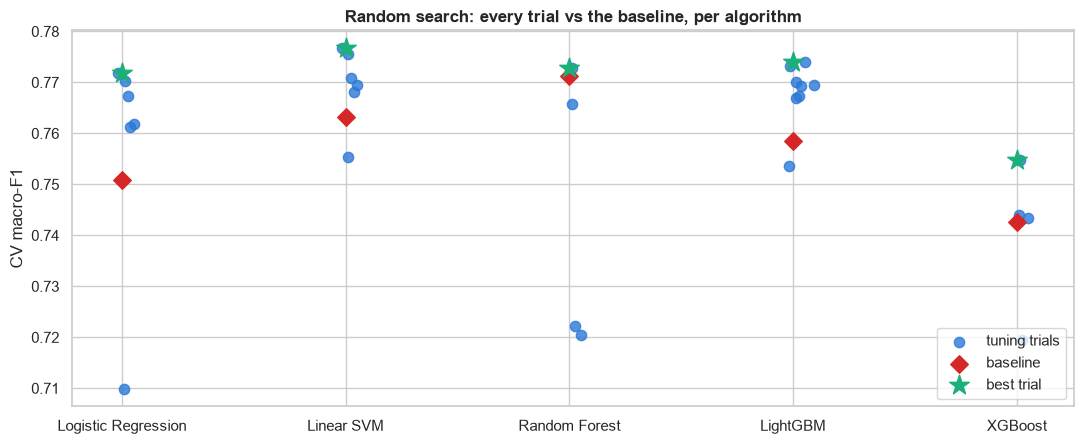

C  alpha  trees  cv_macro_f1  cv_macro_f1_std  cv_c1_recall  cv_c3_recall  fit_s_per_fold  n_estimators  min_samples_leaf max_features  max_depth  colsample_bytree  \
model               trial                                                                                                                                                                             
LightGBM            2         NaN    NaN  300.0       0.7740           0.0019        0.8488        0.6965         43.9978           NaN               NaN          NaN        NaN               0.3   
                    7         NaN    NaN  300.0       0.7731           0.0021        0.8499        0.7113         70.7815           NaN               NaN          NaN        NaN               0.5   
                    4         NaN    NaN  300.0       0.7700           0.0002        0.8367        0.6650         43.1517           NaN               NaN          NaN        NaN               0.5   
Linear SVM          5      0.1997   0.50    NaN       0.7768           0.0072        0.8316        0.6719          7.3961           NaN               NaN          NaN        NaN               NaN   
                    1      0.1306   0.50    NaN       0.7756           0.0072        0.8324        0.6679          6.0716           NaN               NaN          NaN        NaN               NaN   
                    3      0.3980   0.75    NaN       0.7708           0.0067        0.8332        0.6990          8.5967           NaN               NaN          NaN        NaN               NaN   
Logistic Regression 5      0.9437   0.50    NaN       0.7719           0.0047        0.8408        0.7300          6.1738           NaN               NaN          NaN        NaN               NaN   
                    1      0.5489   0.50    NaN       0.7702           0.0056        0.8415        0.7345          5.0100           NaN               NaN          NaN        NaN               NaN   
                    3      2.2757   0.75    NaN       0.7672           0.0029        0.8454        0.7667          6.6694           NaN               NaN          NaN        NaN               NaN   
Random Forest       4         NaN   0.50    NaN       0.7727           0.0052        0.8231        0.6024         13.8571         150.0               1.0         sqrt        NaN               NaN   
                    1         NaN   0.50    NaN       0.7657           0.0041        0.8372        0.7065          5.8202         150.0               4.0         sqrt        NaN               NaN   
                    3         NaN   0.50    NaN       0.7222           0.0102        0.7398        0.4671          1.1556         150.0               1.0         log2       30.0               NaN   
XGBoost             1         NaN    NaN  300.0       0.7548           0.0059        0.8611        0.7457         98.8784           NaN               NaN          NaN        8.0               0.8   
                    4         NaN    NaN  300.0       0.7440           0.0113        0.8741        0.8111         54.3028           NaN               NaN          NaN        6.0               0.3   
                    2         NaN    NaN  300.0       0.7434           0.0071        0.8649        0.8058        114.3442           NaN               NaN          NaN        8.0               0.8   

                           learning_rate  min_child_samples  num_leaves  reg_lambda  subsample  min_child_weight  
model               trial                                                                                         
LightGBM            2             0.0492               20.0       127.0         5.0        1.0               NaN  
                    7             0.0451               10.0       127.0        10.0        1.0               NaN  
                    4             0.1039               10.0        63.0         1.0        0.7               NaN  
Linear SVM          5                NaN                NaN         NaN  

In [33]:
fig, ax = plt.subplots(figsize=(11, 4.6))
for j, name in enumerate(MODEL_NAMES):
    d = search_df[search_df.model == name]
    ax.scatter(np.full(len(d), j) + np.random.RandomState(0).uniform(-0.12, 0.12, len(d)), d.cv_macro_f1, s=55, color="#2a78d6", alpha=.8, label="tuning trials" if j == 0 else None)
    ax.scatter([j], [BASELINE_RESULTS[name]["summary"]["macro_f1_mean"]], marker="D", s=80, color="#d62728", label="baseline" if j == 0 else None, zorder=3)
    ax.scatter([j], [d.cv_macro_f1.max()], marker="*", s=220, color="#1baf7a", label="best trial" if j == 0 else None, zorder=4)
ax.set_xticks(range(len(MODEL_NAMES))); ax.set_xticklabels(MODEL_NAMES); ax.set_ylabel("CV macro-F1")
ax.set_title("Random search: every trial vs the baseline, per algorithm"); ax.legend(loc="lower right")
plt.tight_layout(); plt.savefig(FIG / "07_fig1_search_trials.png", dpi=150, bbox_inches="tight"); plt.show()
display(search_df.sort_values(["model", "cv_macro_f1"], ascending=[True, False]).groupby("model").head(3).round(4).set_index(["model", "trial"]))

## 3. Tuned vs baseline
For each family the better of {baseline, best tuned} (by CV macro-F1) becomes that family's **candidate**. The paired fold-by-fold difference shows whether the gain is consistent or just noise.

In [34]:
CAND = {}      # family -> dict(res=..., origin='tuned'|'baseline')
rows = []
for name in MODEL_NAMES:
    b, t = BASELINE_RESULTS[name], BEST_TUNED[name]
    use_t = t["summary"]["macro_f1_mean"] > b["summary"]["macro_f1_mean"]
    CAND[name] = dict(res=t if use_t else b, origin="tuned" if use_t else "baseline (tuning did not help)")
    delta = [tf["macro_f1"] - bf["macro_f1"] for tf, bf in zip(t["per_fold"], b["per_fold"])]
    rows.append({"Model": name,
                 "Baseline macro-F1": f"{b['summary']['macro_f1_mean']:.4f} +/- {b['summary']['macro_f1_std']:.4f}",
                 "Best tuned macro-F1": f"{t['summary']['macro_f1_mean']:.4f} +/- {t['summary']['macro_f1_std']:.4f}",
                 "Gain": round(t["summary"]["macro_f1_mean"] - b["summary"]["macro_f1_mean"], 4),
                 "Per-fold gain": [round(d, 3) for d in delta], "Folds improved": f"{sum(d > 0 for d in delta)}/{len(delta)}",
                 "Class-1 recall (b -> t)": f"{b['summary']['c1_recall_mean']:.3f} -> {t['summary']['c1_recall_mean']:.3f}",
                 "Class-3 recall (b -> t)": f"{b['summary']['c3_recall_mean']:.3f} -> {t['summary']['c3_recall_mean']:.3f}",
                 "Candidate": CAND[name]["origin"]})
display(pd.DataFrame(rows).set_index("Model"))
for name in MODEL_NAMES:
    r = CAND[name]["res"]
    print(f"{name:20s}", {k: v for k, v in r["params"].items() if k in SPACES[name]}, "| trees:", r["best_iter"] if name in CHECKPOINTS else "-")

,Baseline macro-F1,Best tuned macro-F1,Gain,Per-fold gain,Folds improved,Class-1 recall (b -> t),Class-3 recall (b -> t),Candidate
Model,,,,,,,,
Logistic Regression,0.7509 +/- 0.0012,0.7719 +/- 0.0047,0.0210,"[0.025, 0.015, 0.023]",3/3,0.861 -> 0.841,0.840 -> 0.730,tuned
Linear SVM,0.7633 +/- 0.0050,0.7768 +/- 0.0072,0.0136,"[0.013, 0.01, 0.017]",3/3,0.827 -> 0.832,0.691 -> 0.672,tuned
Random Forest,0.7713 +/- 0.0053,0.7727 +/- 0.0052,0.0014,"[-0.003, 0.004, 0.004]",2/3,0.863 -> 0.823,0.679 -> 0.602,tuned
LightGBM,0.7585 +/- 0.0039,0.7740 +/- 0.0019,0.0155,"[0.014, 0.018, 0.014]",3/3,0.851 -> 0.849,0.709 -> 0.696,tuned
XGBoost,0.7426 +/- 0.0110,0.7548 +/- 0.0059,0.0121,"[0.005, 0.016, 0.016]",3/3,0.875 -> 0.861,0.820 -> 0.746,tuned


Logistic Regression  {'C': 0.943697680900179, 'alpha': 0.5} | trees: -
Linear SVM           {'C': 0.19970893477607088, 'alpha': 0.5} | trees: -
Random Forest        {'n_estimators': 150, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'alpha': 0.5} | trees: -
LightGBM             {'learning_rate': 0.04916087105247033, 'num_leaves': 127, 'min_child_samples': 20, 'colsample_bytree': 0.3, 'subsample': 1.0, 'reg_lambda': 5.0} | trees: 300
XGBoost              {'learning_rate': 0.15084699674171043, 'max_depth': 8, 'min_child_weight': 5, 'subsample': 0.7, 'colsample_bytree': 0.8, 'reg_lambda': 1.0} | trees: 300


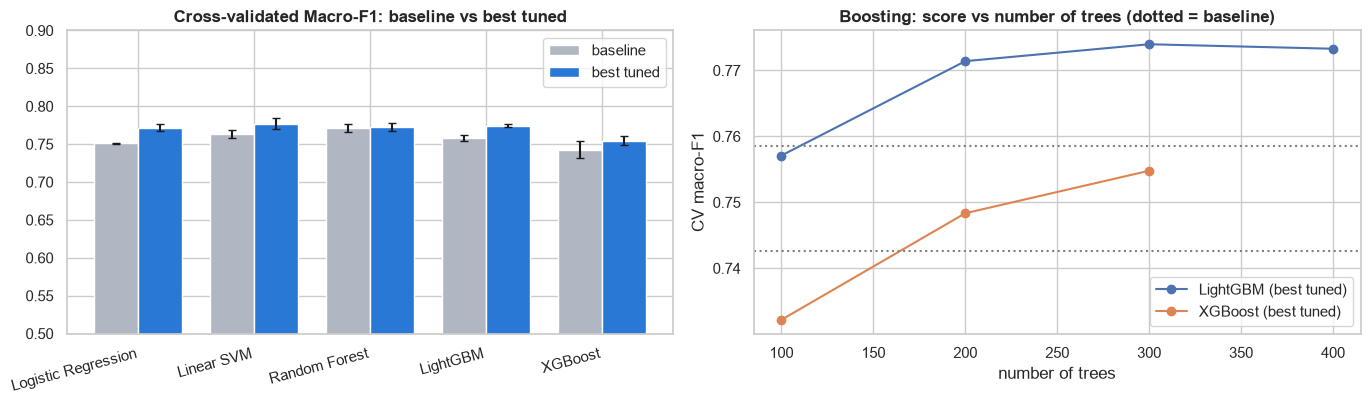

In [35]:
bt = [n for n in MODEL_NAMES if n in CHECKPOINTS]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
x = np.arange(len(MODEL_NAMES)); w = 0.38
axes[0].bar(x - w / 2, [BASELINE_RESULTS[n]["summary"]["macro_f1_mean"] for n in MODEL_NAMES], w, label="baseline", color="#b0b7c3",
            yerr=[BASELINE_RESULTS[n]["summary"]["macro_f1_std"] for n in MODEL_NAMES], capsize=3)
axes[0].bar(x + w / 2, [BEST_TUNED[n]["summary"]["macro_f1_mean"] for n in MODEL_NAMES], w, label="best tuned", color="#2a78d6",
            yerr=[BEST_TUNED[n]["summary"]["macro_f1_std"] for n in MODEL_NAMES], capsize=3)
axes[0].set_xticks(x); axes[0].set_xticklabels(MODEL_NAMES, rotation=15, ha="right"); axes[0].set_ylim(0.5, 0.9); axes[0].legend()
axes[0].set_title("Cross-validated Macro-F1: baseline vs best tuned")
for n in bt:
    c = BEST_TUNED[n]["curve"]
    axes[1].plot(list(c), list(c.values()), marker="o", label=f"{n} (best tuned)")
    axes[1].axhline(BASELINE_RESULTS[n]["summary"]["macro_f1_mean"], ls=":", color="grey")
axes[1].set_xlabel("number of trees"); axes[1].set_ylabel("CV macro-F1"); axes[1].legend()
axes[1].set_title("Boosting: score vs number of trees (dotted = baseline)")
plt.tight_layout(); plt.savefig(FIG / "07_fig2_tuned_vs_baseline.png", dpi=150, bbox_inches="tight"); plt.show()

## 4. Does feature selection help? — number of chi² features `k`
The chi² ranking is computed **inside each fold** from the training window only. A fast, fixed **probe model** (LightGBM, 150 trees, 31 leaves, `colsample 0.5`) is used so that *only* `k` changes between runs.
Decision rule (fixed in advance): adopt a different `k` only if it improves CV macro-F1 by at least **0.003** *and* does not cut Class-1 recall by more than 0.01; otherwise keep k = 5 000 (the pipeline already saved by Notebook 02).

k=  1000: macro-F1 0.7245 +/- 0.0156 | C1 recall 0.844 | 4s/fold
k=  2500: macro-F1 0.7461 +/- 0.0125 | C1 recall 0.861 | 7s/fold
k=  5000: macro-F1 0.7501 +/- 0.0099 | C1 recall 0.865 | 12s/fold
k= 10000: macro-F1 0.7526 +/- 0.0099 | C1 recall 0.864 | 16s/fold
k= 20000: macro-F1 0.7541 +/- 0.0102 | C1 recall 0.863 | 19s/fold

=> chosen k for the tree models: 20000 (changed)


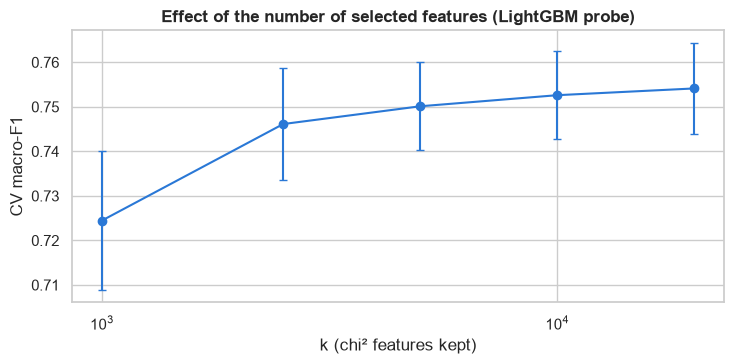

In [36]:
PROBE = dict(n_estimators=150, learning_rate=0.1, num_leaves=31, min_child_samples=20, colsample_bytree=0.5, subsample=1.0, reg_lambda=1.0)
if QUICK_RUN:
    PROBE["n_estimators"] = 40
K_GRID = [1000, 2500, 5000, 10000, 20000]
KS, k_rows = {}, []
for k in K_GRID:
    r = cv_evaluate("LightGBM", PROBE, k=k)
    KS[k] = r; log_experiment(NB, "feature_count_k", "LightGBM(probe)", r, label=f"k={k}")
    s = r["summary"]
    k_rows.append({"k": k, "macro_f1": s["macro_f1_mean"], "std": s["macro_f1_std"], "c1_recall": s["c1_recall_mean"], "c3_recall": s["c3_recall_mean"], "fit_s_per_fold": r["fit_s"]})
    print(f"k={k:>6}: macro-F1 {s['macro_f1_mean']:.4f} +/- {s['macro_f1_std']:.4f} | C1 recall {s['c1_recall_mean']:.3f} | {r['fit_s']:.0f}s/fold")
k_df = pd.DataFrame(k_rows).set_index("k")
ref = k_df.loc[5000]
elig = k_df[(k_df.macro_f1 - ref.macro_f1 >= 0.003) & (k_df.c1_recall - ref.c1_recall >= -0.01)]
K_STAR = int(elig.macro_f1.idxmax()) if len(elig) else 5000
print(f"\n=> chosen k for the tree models: {K_STAR}", "(changed)" if K_STAR != 5000 else "(unchanged - selection beyond 5 000 does not clearly help)")
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.errorbar(k_df.index, k_df.macro_f1, yerr=k_df["std"], marker="o", capsize=3, color="#2a78d6"); ax.set_xscale("log")
ax.set_xlabel("k (chi² features kept)"); ax.set_ylabel("CV macro-F1"); ax.set_title("Effect of the number of selected features (LightGBM probe)")
plt.tight_layout(); plt.savefig(FIG / "07_fig3_feature_count.png", dpi=150, bbox_inches="tight"); plt.show()

## 5. Do the engineered features earn their place? — feature-group ablation
Same probe model, `k = 5 000`; one feature group is **removed at a time** and the CV score re-measured. A group whose removal lowers the score is useful. This directly tests the feature engineering done in Notebook 02 (building-history features, calendar features, respondent type, DOB unit).

without building history (BIN_PRIOR_*, days since prev)        macro-F1 0.7506  (+0.0004)
without calendar (month, weekday, weekend)                     macro-F1 0.7502  (+0.0000)
without respondent type                                        macro-F1 0.7500  (-0.0001)
without DOB unit + DOB-violation flag                          macro-F1 0.7478  (-0.0024)
without violation type + borough                               macro-F1 0.7375  (-0.0126)
without aggravation level + text length                        macro-F1 0.7478  (-0.0023)
TEXT ONLY (all structured removed)                             macro-F1 0.7342  (-0.0159)
STRUCTURED ONLY (all text removed)                             macro-F1 0.4524  (-0.2978)


,macro_f1,c1_recall,c3_recall,n_features,change vs all
variant,,,,,
ALL features (reference),0.7501,0.8652,0.8069,5000,0.0000
"without building history (BIN_PRIOR_*, days since prev)",0.7506,0.8638,0.8049,4997,0.0004
"without calendar (month, weekday, weekend)",0.7502,0.8658,0.8031,4982,0.0000
without respondent type,0.7500,0.8651,0.8031,4996,-0.0001
without DOB unit + DOB-violation flag,0.7478,0.8619,0.8016,4978,-0.0024
without violation type + borough,0.7375,0.8634,0.7875,4984,-0.0126
without aggravation level + text length,0.7478,0.8637,0.8079,4999,-0.0023
TEXT ONLY (all structured removed),0.7342,0.8535,0.7949,4936,-0.0159
STRUCTURED ONLY (all text removed),0.4524,0.5246,0.7116,64,-0.2978


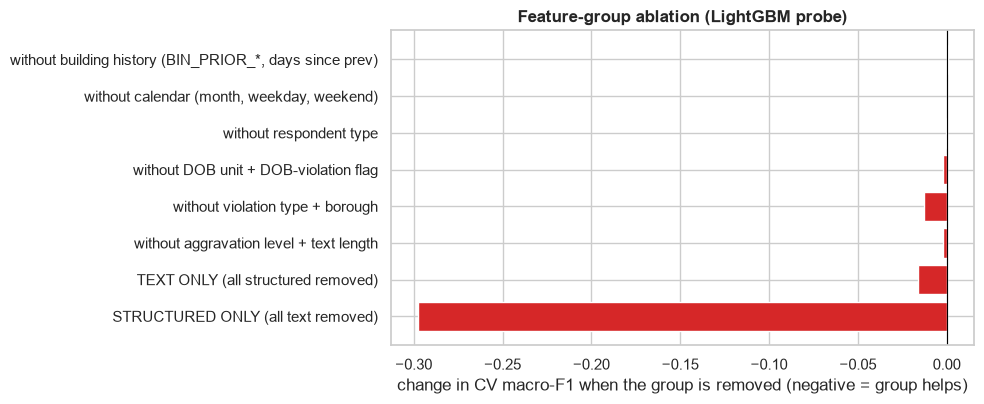

In [37]:
GROUPS = {
    "building history (BIN_PRIOR_*, days since prev)": ["num__BIN_PRIOR_VIOLATIONS", "num__BIN_PRIOR_CLASS1", "num__BIN_DAYS_SINCE_PREV"],
    "calendar (month, weekday, weekend)":              ["cat__ISSUE_MONTH", "cat__ISSUE_DAYOFWEEK", "bin__IS_WEEKEND"],
    "respondent type":                                 ["cat__RESPONDENT_TYPE"],
    "DOB unit + DOB-violation flag":                   ["cat__DOB_UNIT", "bin__HAS_DOB_VIOLATION"],
    "violation type + borough":                        ["cat__VIOLATION_TYPE", "cat__BORO"],
    "aggravation level + text length":                 ["num__AGGRAVATED_ORD", "num__DESC_WORDS"],
}
EXTREMES = {"TEXT ONLY (all structured removed)": ["cat__", "bin__", "num__"], "STRUCTURED ONLY (all text removed)": ["text__"]}
ref_res = KS[5000]
abl_rows = [{"variant": "ALL features (reference)", "macro_f1": ref_res["summary"]["macro_f1_mean"], "c1_recall": ref_res["summary"]["c1_recall_mean"],
             "c3_recall": ref_res["summary"]["c3_recall_mean"], "n_features": ref_res["n_features"]}]
for label, frags in {**{f"without {g}": v for g, v in GROUPS.items()}, **EXTREMES}.items():
    r = cv_evaluate("LightGBM", PROBE, k=5000, drop=frags)
    log_experiment(NB, "feature_group_ablation", "LightGBM(probe)", r, label=label)
    s = r["summary"]
    abl_rows.append({"variant": label, "macro_f1": s["macro_f1_mean"], "c1_recall": s["c1_recall_mean"], "c3_recall": s["c3_recall_mean"], "n_features": r["n_features"]})
    print(f"{label:62s} macro-F1 {s['macro_f1_mean']:.4f}  ({s['macro_f1_mean'] - ref_res['summary']['macro_f1_mean']:+.4f})")
abl = pd.DataFrame(abl_rows).set_index("variant")
abl["change vs all"] = abl.macro_f1 - abl.macro_f1.iloc[0]
display(abl.round(4))
fig, ax = plt.subplots(figsize=(10, 4.2))
d = abl.iloc[1:]["change vs all"][::-1]
ax.barh(d.index, d.values, color=["#d62728" if v < 0 else "#1baf7a" for v in d.values]); ax.axvline(0, color="black", lw=.8)
ax.set_xlabel("change in CV macro-F1 when the group is removed (negative = group helps)"); ax.set_title("Feature-group ablation (LightGBM probe)")
plt.tight_layout(); plt.savefig(FIG / "07_fig4_feature_ablation.png", dpi=150, bbox_inches="tight"); plt.show()

## 6. Other modelling choice — strength of class weighting
Weights are `balanced_weight ** alpha`: `alpha = 0` ignores imbalance, `alpha = 1` is fully balanced (Class 3 ≈ 14× Class 2). Same probe model, `k = K*`. Rule (fixed in advance): adopt a different `alpha` only if CV macro-F1 improves by ≥ 0.003 and Class-1 recall does not drop by more than 0.01.

alpha=0.0 : macro-F1 0.7618 | C1 recall 0.805 / precision 0.827 | C3 recall 0.542 / precision 0.721
alpha=0.5 : macro-F1 0.7697 | C1 recall 0.839 / precision 0.806 | C3 recall 0.704 / precision 0.599
alpha=0.75: macro-F1 0.7642 | C1 recall 0.853 / precision 0.796 | C3 recall 0.761 / precision 0.547
alpha=1.0 : macro-F1 0.7541 | C1 recall 0.863 / precision 0.787 | C3 recall 0.801 / precision 0.499

=> chosen class-weight strength alpha: 0.75 (changed)


,macro_f1,c1_recall,c1_precision,c3_recall,c3_precision
alpha,,,,,
0.00,0.7618,0.8053,0.8273,0.5418,0.7213
0.50,0.7697,0.8393,0.8064,0.7035,0.5990
0.75,0.7642,0.8533,0.7959,0.7610,0.5474
1.00,0.7541,0.8630,0.7875,0.8012,0.4993


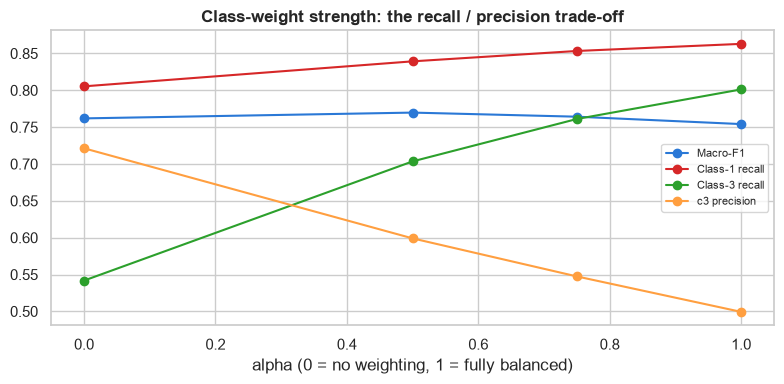

In [38]:
A_GRID = [0.0, 0.5, 0.75, 1.0]
AL, a_rows = {}, []
for a in A_GRID:
    r = cv_evaluate("LightGBM", PROBE, k=K_STAR, alpha=a)
    AL[a] = r; log_experiment(NB, "class_weight_alpha", "LightGBM(probe)", r, label=f"alpha={a}")
    s = r["summary"]
    a_rows.append({"alpha": a, "macro_f1": s["macro_f1_mean"], "c1_recall": s["c1_recall_mean"], "c1_precision": s["c1_precision_mean"],
                   "c3_recall": s["c3_recall_mean"], "c3_precision": s["c3_precision_mean"]})
    print(f"alpha={a:<4}: macro-F1 {s['macro_f1_mean']:.4f} | C1 recall {s['c1_recall_mean']:.3f} / precision {s['c1_precision_mean']:.3f} | C3 recall {s['c3_recall_mean']:.3f} / precision {s['c3_precision_mean']:.3f}")
a_df = pd.DataFrame(a_rows).set_index("alpha")
ref = a_df.loc[1.0]
elig = a_df[(a_df.macro_f1 - ref.macro_f1 >= 0.003) & (a_df.c1_recall - ref.c1_recall >= -0.01)]
ALPHA_STAR = float(elig.macro_f1.idxmax()) if len(elig) else 1.0
print(f"\n=> chosen class-weight strength alpha: {ALPHA_STAR}", "(changed)" if ALPHA_STAR != 1.0 else "(unchanged - fully balanced weights stay)")
display(a_df.round(4))
fig, ax = plt.subplots(figsize=(8, 4))
for c, col in [("macro_f1", "#2a78d6"), ("c1_recall", "#d62728"), ("c3_recall", "#2ca02c"), ("c3_precision", "#ff9f40")]:
    ax.plot(a_df.index, a_df[c], marker="o", label=METRIC_LABELS.get(c, c.replace("_", " ")), color=col)
ax.set_xlabel("alpha (0 = no weighting, 1 = fully balanced)"); ax.legend(fontsize=8); ax.set_title("Class-weight strength: the recall / precision trade-off")
plt.tight_layout(); plt.savefig(FIG / "07_fig5_class_weight.png", dpi=150, bbox_inches="tight"); plt.show()

## 7. Final model selection
### 7.1 The selection rule (declared before scoring)
Candidates = the best configuration of every family (§3), plus **LightGBM / XGBoost / Random Forest re-evaluated with the adopted `k = K*` and `alpha = ALPHA*`** from §4 and §6 if either changed (so a feature/weight decision is judged on equal terms).

1. **Eligibility (guard-rails).** A candidate must have CV **Class-1 recall ≥ 0.80** (safety floor), CV **Class-3 recall ≥ 0.55** (the rare class must not be abandoned) and must **output class probabilities** (the frontend shows a confidence and flags uncertain cases for human review — the Linear SVM only gives margins, so it is reported but not eligible).
2. **Ranking.** Among eligible candidates, highest **CV macro-F1**.
3. **Tie-break.** If the runner-up is within **0.005** macro-F1, prefer the higher **Class-1 recall**; if still within 0.005, prefer the **faster predictor**.

The locked test set plays **no role** in this rule.

In [39]:
CANDIDATES = {}
for name in MODEL_NAMES:
    CANDIDATES[f"{name} [{CAND[name]['origin'].split(' ')[0]}]"] = dict(family=name, res=CAND[name]["res"], k=CAND[name]["res"]["params"].get("k"), alpha=CAND[name]["res"]["params"].get("alpha"))

if (K_STAR != 5000 or ALPHA_STAR != 1.0):
    for name in ["LightGBM", "XGBoost", "Random Forest"]:
        base_p = {k: v for k, v in CAND[name]["res"]["params"].items()}
        r = cv_evaluate(name, {**base_p, **({"n_estimators": CAND[name]["res"]["best_iter"]} if name in CHECKPOINTS else {})}, k=K_STAR, alpha=ALPHA_STAR)
        log_experiment(NB, "adopted_k_alpha", name, r, label=f"k={K_STAR}, alpha={ALPHA_STAR}")
        if r["summary"]["macro_f1_mean"] > CAND[name]["res"]["summary"]["macro_f1_mean"]:
            CANDIDATES[f"{name} [tuned+k/alpha]"] = dict(family=name, res=r, k=K_STAR, alpha=ALPHA_STAR)
            CANDIDATES.pop(f"{name} [{CAND[name]['origin'].split(' ')[0]}]", None)
            print(f"{name}: adopted k={K_STAR}, alpha={ALPHA_STAR} -> macro-F1 {r['summary']['macro_f1_mean']:.4f}")
        else:
            print(f"{name}: k/alpha change did not help ({r['summary']['macro_f1_mean']:.4f}) - keeping the earlier candidate")
print("\nCandidates:", list(CANDIDATES))

LightGBM: adopted k=20000, alpha=0.75 -> macro-F1 0.7748
XGBoost: adopted k=20000, alpha=0.75 -> macro-F1 0.7654
Random Forest: k/alpha change did not help (0.7723) - keeping the earlier candidate

Candidates: ['Logistic Regression [tuned]', 'Linear SVM [tuned]', 'Random Forest [tuned]', 'LightGBM [tuned+k/alpha]', 'XGBoost [tuned+k/alpha]']


In [40]:
HAS_PROBA = {"Logistic Regression": True, "Linear SVM": False, "Random Forest": True, "LightGBM": True, "XGBoost": True}
C1_FLOOR, C3_FLOOR, TIE = 0.80, 0.55, 0.005

# prediction speed on the validation block of the last fold (ms per 1000 rows) - used only as the last tie-break
def predict_ms(cand):
    f = FOLDS[-1]; p = {**cand["res"]["params"]}
    Xtr, Xva = fold_matrices(f, VIEW[cand["family"]], p.get("k"))
    n_it = cand["res"]["best_iter"] if cand["family"] in CHECKPOINTS else None
    if n_it: p["n_estimators"] = n_it
    m, kw = build_model(cand["family"], p, f["y_tr"]); m.fit(Xtr, f["y_tr"], **kw)
    t0 = time.time(); score_model(cand["family"], m, Xva, n_it); return (time.time() - t0) / Xva.shape[0] * 1e6

rows = []
for cname, c in CANDIDATES.items():
    s = c["res"]["summary"]
    ok1, ok2, ok3 = s["c1_recall_mean"] >= C1_FLOOR, s["c3_recall_mean"] >= C3_FLOOR, HAS_PROBA[c["family"]]
    rows.append({"Candidate": cname, "CV macro-F1": s["macro_f1_mean"], "std": s["macro_f1_std"], "CV C1 recall": s["c1_recall_mean"], "CV C1 precision": s["c1_precision_mean"],
                 "CV C3 recall": s["c3_recall_mean"], "C1 >= 0.80": ok1, "C3 >= 0.55": ok2, "has probabilities": ok3, "eligible": ok1 and ok2 and ok3})
trail = pd.DataFrame(rows).set_index("Candidate").sort_values("CV macro-F1", ascending=False)
display(trail.round(4))

elig = trail[trail.eligible]
assert len(elig), "No candidate satisfies the guard-rails - revisit the floors / the search (do NOT look at the test set to decide)."
top = elig.index[0]
close = [c for c in elig.index if elig.loc[top, "CV macro-F1"] - elig.loc[c, "CV macro-F1"] <= TIE]
steps = [f"Step 1 (eligibility): {len(elig)} of {len(trail)} candidates pass the guard-rails: {list(elig.index)}",
         f"Step 2 (ranking): highest CV macro-F1 = {top} ({elig.loc[top, 'CV macro-F1']:.4f})"]
winner = top
if len(close) > 1:
    c1_best = elig.loc[close, "CV C1 recall"]
    near = [c for c in close if c1_best.max() - c1_best[c] <= TIE]
    steps.append(f"Step 3 (tie-break): within {TIE} macro-F1 of the top: {close}; highest Class-1 recall = {c1_best.idxmax()} ({c1_best.max():.4f})")
    winner = c1_best.idxmax()
    if len(near) > 1:
        lat = {c: predict_ms(CANDIDATES[c]) for c in near}
        winner = min(lat, key=lat.get)
        steps.append(f"          still tied on recall -> faster predictor: {winner} ({lat[winner]:.0f} ms / 1000 rows)")
else:
    steps.append("Step 3 (tie-break): not needed - no eligible runner-up within 0.005 macro-F1.")
FINAL_NAME, FINAL = winner, CANDIDATES[winner]
print("\n".join(steps)); print(f"\nFINAL MODEL SELECTED: {FINAL_NAME}")

,CV macro-F1,std,CV C1 recall,CV C1 precision,CV C3 recall,C1 >= 0.80,C3 >= 0.55,has probabilities,eligible
Candidate,,,,,,,,,
Linear SVM [tuned],0.7768,0.0072,0.8316,0.8206,0.6719,True,True,False,False
LightGBM [tuned+k/alpha],0.7748,0.0037,0.8422,0.8142,0.6498,True,True,True,True
Random Forest [tuned],0.7727,0.0052,0.8231,0.8158,0.6024,True,True,True,True
Logistic Regression [tuned],0.7719,0.0047,0.8408,0.8138,0.7300,True,True,True,True
XGBoost [tuned+k/alpha],0.7654,0.0034,0.8495,0.7964,0.7060,True,True,True,True


Step 1 (eligibility): 4 of 5 candidates pass the guard-rails: ['LightGBM [tuned+k/alpha]', 'Random Forest [tuned]', 'Logistic Regression [tuned]', 'XGBoost [tuned+k/alpha]']
Step 2 (ranking): highest CV macro-F1 = LightGBM [tuned+k/alpha] (0.7748)
Step 3 (tie-break): within 0.005 macro-F1 of the top: ['LightGBM [tuned+k/alpha]', 'Random Forest [tuned]', 'Logistic Regression [tuned]']; highest Class-1 recall = LightGBM [tuned+k/alpha] (0.8422)
          still tied on recall -> faster predictor: Logistic Regression [tuned] (0 ms / 1000 rows)

FINAL MODEL SELECTED: Logistic Regression [tuned]


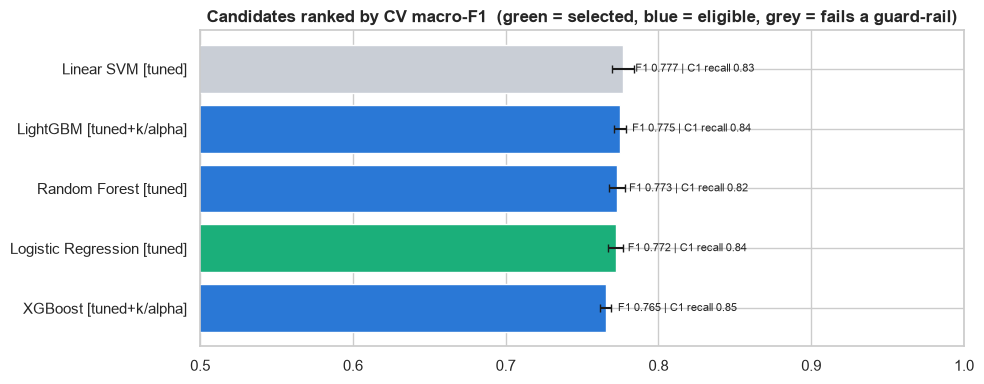

In [41]:
fig, ax = plt.subplots(figsize=(10, 4))
tr_ = trail.iloc[::-1]
cols = ["#1baf7a" if c == FINAL_NAME else ("#2a78d6" if e else "#c9ced6") for c, e in zip(tr_.index, tr_.eligible)]
ax.barh(tr_.index, tr_["CV macro-F1"], xerr=tr_["std"], color=cols, capsize=3)
for y_, (v, r_) in enumerate(zip(tr_["CV macro-F1"], tr_["CV C1 recall"])):
    ax.text(v + 0.008, y_, f"F1 {v:.3f} | C1 recall {r_:.2f}", va="center", fontsize=8)
ax.set_xlim(0.5, 1.0); ax.set_title("Candidates ranked by CV macro-F1  (green = selected, blue = eligible, grey = fails a guard-rail)")
plt.tight_layout(); plt.savefig(FIG / "07_fig6_selection.png", dpi=150, bbox_inches="tight"); plt.show()

### 7.2 Final model — confirmation run on the CV folds
The chosen configuration is re-run once with `keep_oof=True` to keep its out-of-fold scores from the newest validation block. These are used to pick the **human-review confidence threshold** (§8.3) *without* looking at the test set.

In [42]:
FINAL_FAMILY = FINAL["family"]
FP = {k: v for k, v in FINAL["res"]["params"].items()}
if FINAL_FAMILY in CHECKPOINTS:
    FP["n_estimators"] = FINAL["res"]["best_iter"]          # number of trees found by the staged search
FINAL_K = FP.get("k") if VIEW[FINAL_FAMILY] == "tree" else None
CONF = cv_evaluate(FINAL_FAMILY, FP, keep_oof=True)
log_experiment(NB, "final_candidate_confirmation", FINAL_FAMILY, CONF, label=FINAL_NAME)
print(f"Final configuration ({FINAL_NAME}):")
print(json.dumps(clean_params(FP), indent=2, default=str))
print(f"\nConfirmation CV macro-F1 {CONF['summary']['macro_f1_mean']:.4f} +/- {CONF['summary']['macro_f1_std']:.4f} "
      f"(same as the search result: {FINAL['res']['summary']['macro_f1_mean']:.4f})")

Final configuration (Logistic Regression [tuned]):
{
  "C": 0.943697680900179,
  "max_iter": 300,
  "alpha": 0.5
}

Confirmation CV macro-F1 0.7719 +/- 0.0047 (same as the search result: 0.7719)


## 8. Train the final model and evaluate it — once — on the locked test set
The final model is trained on the **whole training period** with the final preprocessing:

* a **linear-family** model uses the saved `preprocess_linear.joblib` (all features);
* a **tree-family** model uses the saved `features` step plus a chi² `SelectKBest(k)` fitted on the whole training period. For `k = 5 000` this reproduces the stored `X_train_tree.npz` of Notebook 02 exactly (checked below), so the exported pipeline is identical to what was used in training.

Nothing is changed after this evaluation.

In [43]:
saved_linear_pre = joblib.load(ART / "preprocess_linear.joblib")

def build_final_preprocess(view, k):
    if view == "linear":
        return saved_linear_pre
    feats = saved_linear_pre.named_steps["features"]
    XF = feats.transform(train_df[FEATURES]).tocsr()
    sel = SelectKBest(chi2, k=int(k)).fit(XF, y_train)
    return Pipeline([("features", feats), ("select", sel)])

PRE = build_final_preprocess(VIEW[FINAL_FAMILY], FINAL_K)
X_tr_final = PRE.transform(train_df[FEATURES]).tocsr()
X_te_final = PRE.transform(test_df[FEATURES]).tocsr()

# consistency with Notebook 02's stored matrices (train/serve skew guard)
stored_tr, stored_te = STORED[VIEW[FINAL_FAMILY]]
if (VIEW[FINAL_FAMILY] == "linear" or FINAL_K == 5000) and not QUICK_RUN:
    d_tr, d_te = abs(X_tr_final - stored_tr).max(), abs(X_te_final - stored_te).max()
    print(f"max |pipeline output - stored matrix|: train {d_tr:.2e}, test {d_te:.2e}")
    assert d_tr < 1e-5 and d_te < 1e-5, "Exported preprocessing does not reproduce the matrices from Notebook 02."
print("final matrices:", X_tr_final.shape, X_te_final.shape)

t0 = time.time()
FINAL_MODEL, fkw = build_model(FINAL_FAMILY, FP, y_train)
FINAL_MODEL.fit(X_tr_final, y_train, **fkw)
FIT_SECONDS = time.time() - t0
S_te = score_model(FINAL_FAMILY, FINAL_MODEL, X_te_final)
pred_te = S_te.argmax(1)
TEST = evaluate(y_test, pred_te, S_te)
print(f"trained in {FIT_SECONDS:.0f}s")
print(f"\nTEST  macro-F1 {TEST['macro_f1']:.4f} | accuracy {TEST['accuracy']:.4f} | Class-1 recall {TEST['c1_recall']:.4f} | "
      f"Class-1 precision {TEST['c1_precision']:.4f} | Class-3 recall {TEST['c3_recall']:.4f} | AUC {TEST['macro_auc_ovr']:.4f}")
print(f"CV    macro-F1 {CONF['summary']['macro_f1_mean']:.4f} +/- {CONF['summary']['macro_f1_std']:.4f}   (test - CV = {TEST['macro_f1'] - CONF['summary']['macro_f1_mean']:+.4f})")
print()
print(classification_report(y_test, pred_te, target_names=[f"{c} ({CLASS_MEANING[c]})" for c in CLASS_NAMES], digits=4))

max |pipeline output - stored matrix|: train 2.98e-08, test 2.97e-08
final matrices: (81780, 40072) (20554, 40072)
trained in 13s

TEST  macro-F1 0.7711 | accuracy 0.8223 | Class-1 recall 0.8611 | Class-1 precision 0.7913 | Class-3 recall 0.7185 | AUC 0.9423
CV    macro-F1 0.7719 +/- 0.0047   (test - CV = -0.0008)

                                   precision    recall  f1-score   support

CLASS - 1 (Immediately hazardous)     0.7913    0.8611    0.8248      8455
                CLASS - 2 (Major)     0.8707    0.8007    0.8342     11282
               CLASS - 3 (Lesser)     0.6008    0.7185    0.6544       817

                         accuracy                         0.8223     20554
                        macro avg     0.7543    0.7935    0.7711     20554
                     weighted avg     0.8273    0.8223    0.8232     20554



Baseline Logistic Regression on test (Notebook 06): macro-F1 0.7496, Class-1 recall 0.8798  ->  final model: 0.7711, 0.8611
95% bootstrap CI on test: {'macro_f1': '[0.761, 0.781]', 'c1_recall': '[0.855, 0.867]', 'c3_recall': '[0.691, 0.750]'}


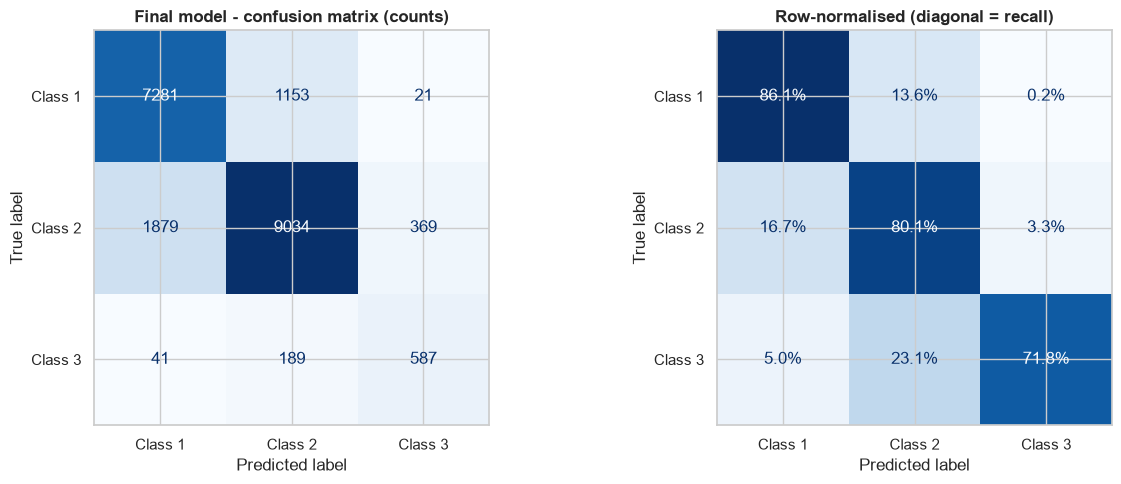

Hazardous (Class 1) violations: 8,455 | caught 7,281 (86.1%) | called Class 2: 1,153 | called Class 3: 21 (0.25%)
Alerts for Class 1: 9,201 | correct 7,281 (79.1%) | false alarms 1,920


In [44]:
# --- compare with the same family's untuned baseline on test (from Notebook 06) and a bootstrap confidence interval
b06 = RESULTS / "stage6_baseline_test.csv"
if b06.exists() and FINAL_FAMILY in pd.read_csv(b06, index_col=0).index:
    bt_ = pd.read_csv(b06, index_col=0).loc[FINAL_FAMILY]
    print(f"Baseline {FINAL_FAMILY} on test (Notebook 06): macro-F1 {bt_['Macro-F1']:.4f}, Class-1 recall {bt_['Class-1 recall']:.4f}  ->  "
          f"final model: {TEST['macro_f1']:.4f}, {TEST['c1_recall']:.4f}")
rng = np.random.RandomState(RANDOM_STATE)
boot = []
for _ in range(200 if not QUICK_RUN else 30):
    idx = rng.randint(0, len(y_test), len(y_test))
    boot.append([evaluate(y_test[idx], pred_te[idx])[m] for m in ("macro_f1", "c1_recall", "c3_recall")])
boot = np.array(boot)
CI = {m: (float(np.percentile(boot[:, j], 2.5)), float(np.percentile(boot[:, j], 97.5))) for j, m in enumerate(("macro_f1", "c1_recall", "c3_recall"))}
print("95% bootstrap CI on test:", {m: f"[{lo:.3f}, {hi:.3f}]" for m, (lo, hi) in CI.items()})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(y_test, pred_te, labels=[0, 1, 2])
ConfusionMatrixDisplay(cm, display_labels=SHORT).plot(ax=axes[0], cmap="Blues", colorbar=False, values_format="d"); axes[0].set_title("Final model - confusion matrix (counts)")
ConfusionMatrixDisplay.from_predictions(y_test, pred_te, labels=[0, 1, 2], display_labels=SHORT, normalize="true", cmap="Blues", ax=axes[1], colorbar=False, values_format=".1%")
axes[1].set_title("Row-normalised (diagonal = recall)")
plt.tight_layout(); plt.savefig(FIG / "07_fig7_final_confusion.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"Hazardous (Class 1) violations: {cm[0].sum():,} | caught {cm[0, 0]:,} ({cm[0, 0] / cm[0].sum():.1%}) | called Class 2: {cm[0, 1]:,} | called Class 3: {cm[0, 2]:,} ({cm[0, 2] / cm[0].sum():.2%})")
print(f"Alerts for Class 1: {cm[:, 0].sum():,} | correct {cm[0, 0]:,} ({cm[0, 0] / cm[:, 0].sum():.1%}) | false alarms {cm[1, 0] + cm[2, 0]:,}")

### 8.1 How does performance change over the test period? (drift check)
The test period is the newest data. A falling trend would argue for periodic retraining.

,rows,macro_f1,c1_recall,c1_share_true
month,,,,
2026-05,3124,0.7527,0.8571,0.4235
2026-06,5434,0.7791,0.8824,0.4069
2026-07,5979,0.7870,0.8569,0.3845
2026-08,4815,0.7598,0.8511,0.4353
2026-09,1202,0.7382,0.8403,0.4376


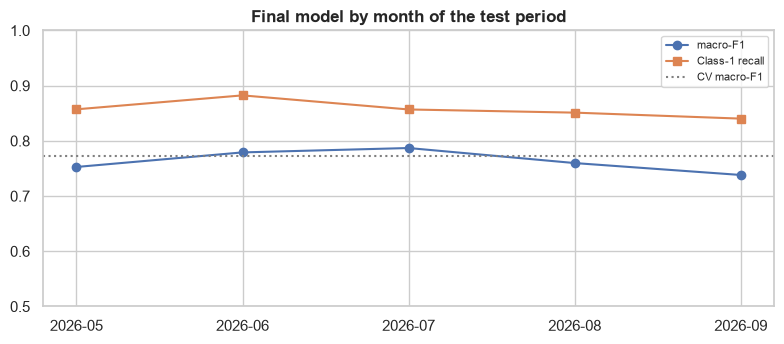

In [45]:
m = test_df["ISSUE_DATE"].dt.to_period("M")
drift = []
for per in sorted(m.unique()):
    mask = (m == per).to_numpy()
    if mask.sum() >= 200:
        e = evaluate(y_test[mask], pred_te[mask]); drift.append({"month": str(per), "rows": int(mask.sum()), "macro_f1": e["macro_f1"], "c1_recall": e["c1_recall"], "c1_share_true": float((y_test[mask] == 0).mean())})
drift = pd.DataFrame(drift).set_index("month"); display(drift.round(4))
if len(drift) > 1:
    fig, ax = plt.subplots(figsize=(8, 3.6))
    ax.plot(drift.index, drift.macro_f1, marker="o", label="macro-F1"); ax.plot(drift.index, drift.c1_recall, marker="s", label="Class-1 recall")
    ax.axhline(CONF["summary"]["macro_f1_mean"], ls=":", color="grey", label="CV macro-F1"); ax.set_ylim(0.5, 1); ax.legend(fontsize=8); ax.set_title("Final model by month of the test period")
    plt.tight_layout(); plt.savefig(FIG / "07_fig8_monthly_drift.png", dpi=150, bbox_inches="tight"); plt.show()

### 8.2 What does the final model rely on? (interpretability)

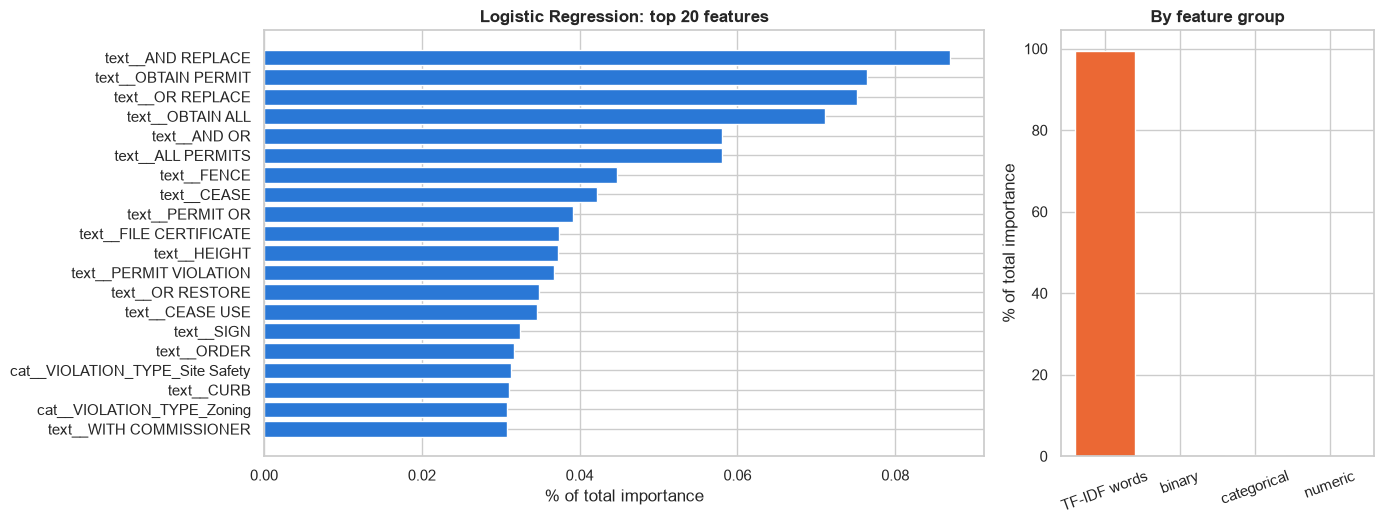

Group shares (%): {'TF-IDF words': 99.5, 'binary': 0.0, 'categorical': 0.4, 'numeric': 0.0}
Final-feature leakage-name check (should be empty): ['text__HAZARDOUS', 'text__HAZARDOUS CONDITION', 'text__TO HAZARDOUS', 'text__HAZARDOUSLY', 'text__ALL HAZARDOUS', 'text__CAUSING HAZARDOUS', 'text__HAZARDOUS CONDITIONS', 'text__IS HAZARDOUS', 'text__OBSERVED HAZARDOUS', 'text__SAFETY HAZARDOUS', 'text__IMMEDIATE HAZARDOUS', 'text__BEEN HAZARDOUSLY', 'text__HAZARDOUSLY DONE', 'text__CREATING HAZARDOUS', 'text__HAZARDOUS CON', 'text__HAZARDOUS STATE', 'text__UNSAFE HAZARDOUS', 'text__AND HAZARDOUS', 'text__CORRECT HAZARDOUS', 'text__IN HAZARDOUS', 'text__HAZARDOUS CONDITIO', 'text__HAZARDOUS UNSAFE', 'text__CREATE HAZARDOUS', 'text__CREATES HAZARDOUS', 'text__HAZARDOUS CONDITI', 'text__MAJORITY', 'text__HAZARDOUS COND', 'text__POTENTIAL HAZARDOUS', 'text__PRODUCING HAZARDOUS', 'text__HAZARDOUS TO', 'text__MAJORITY OF', 'text__HAZARDOUS CO', 'text__POTENTIALLY HAZARDOUS', 'text__HAZARDOUS FOR', 

In [46]:
feat_names = np.asarray(PRE.named_steps["features"].get_feature_names_out())
if "select" in PRE.named_steps:
    feat_names = feat_names[PRE.named_steps["select"].get_support()]
IMPORTANCE_TOP = None
if FINAL_FAMILY == "LightGBM":
    imp = pd.Series(FINAL_MODEL.booster_.feature_importance(importance_type="gain"), index=feat_names)
elif FINAL_FAMILY == "XGBoost":
    imp = pd.Series(FINAL_MODEL.get_booster().get_score(importance_type="total_gain")).reindex([f"f{i}" for i in range(len(feat_names))]).fillna(0)
    imp.index = feat_names
elif FINAL_FAMILY == "Random Forest":
    imp = pd.Series(FINAL_MODEL.feature_importances_, index=feat_names)
else:
    imp = pd.Series(np.abs(FINAL_MODEL.coef_).sum(0), index=feat_names)
imp = imp.sort_values(ascending=False)
grp = imp.groupby(lambda n: {"text": "TF-IDF words", "cat": "categorical", "num": "numeric", "bin": "binary"}.get(n.split("__")[0], "other")).sum()
grp = (grp / grp.sum() * 100).round(1)
IMPORTANCE_TOP = [(n, float(v)) for n, v in (imp / imp.sum()).head(20).items()]
fig, ax = plt.subplots(1, 2, figsize=(14, 5.4), gridspec_kw={"width_ratios": [2.3, 1]})
t_ = (imp / imp.sum() * 100).head(20)[::-1]; ax[0].barh(t_.index, t_.values, color="#2a78d6"); ax[0].set_xlabel("% of total importance"); ax[0].set_title(f"{FINAL_FAMILY}: top 20 features")
ax[1].bar(grp.index, grp.values, color="#eb6834"); ax[1].set_ylabel("% of total importance"); ax[1].tick_params(axis="x", rotation=20); ax[1].set_title("By feature group")
plt.tight_layout(); plt.savefig(FIG / "07_fig9_final_importance.png", dpi=150, bbox_inches="tight"); plt.show()
leak_terms = ["INFRACTION", "PENAL", "AMOUNT", "BALANCE", "HEARING", "CERTIFICATION", "ECB_", "RESPONDENT_NAME", "RESPONDENT_STREET", "BLOCK", "LOT", "SERVED"]
structured = [n for n in imp.index if not n.startswith("text__")]            # column-name check applies to structured features only
text_leak = ["CLASS 1", "CLASS 2", "CLASS 3", "HAZARDOUS", "MAJOR", "LESSER"]   # words masked in Notebook 02 must not come back as TF-IDF terms
hits = [n for n in structured if any(t in n.upper() for t in leak_terms)] + \
       [n for n in imp.index if n.startswith("text__") and any(t in n.upper() for t in text_leak)]
print("Group shares (%):", grp.to_dict()); print("Final-feature leakage-name check (should be empty):", hits)

### 8.3 Confidence and human review — a rule for the frontend
The model is a triage aid. Predictions with low confidence can be flagged for a human inspector. The threshold is chosen on the **out-of-fold validation scores** (newest CV block), never on the test set: the smallest confidence threshold at which the *automatically handled* predictions reach **≥ 90 % accuracy** (fallback 0.80). The test set then only *reports* what that choice does.

Chosen human-review threshold (from validation): 0.65


,,auto-handled %,accuracy on auto-handled,Class-1 caught (model alone) %,Class-1 caught (model + human on flagged) %
,threshold,,,,
validation (out-of-fold),0.65,80.91,0.90,82.91,91.72
test (reporting only),0.65,79.14,0.89,86.11,93.97


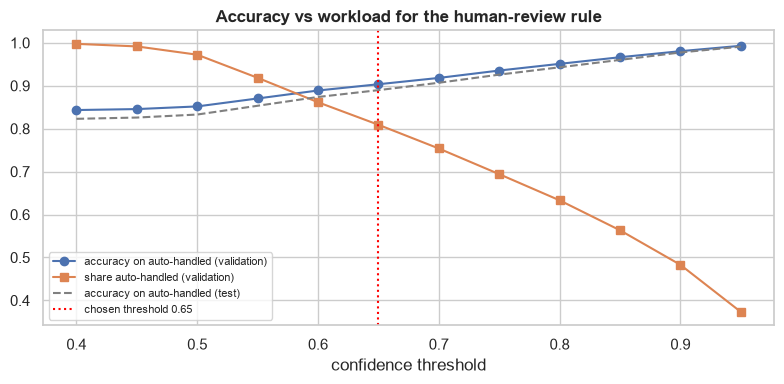

In [47]:
y_oof, S_oof = CONF["oof"]
if FINAL_FAMILY == "Linear SVM":
    raise RuntimeError("The selection rule requires probabilities; the SVM cannot be the final model.")
def review_curve(y, S, grid):
    conf, pr = S.max(1), S.argmax(1); out = []
    for t in grid:
        auto = conf >= t
        hum = ~auto
        c1 = (y == 0)
        out.append({"threshold": t, "auto-handled %": auto.mean() * 100, "accuracy on auto-handled": (pr[auto] == y[auto]).mean() if auto.any() else np.nan,
                    "Class-1 caught (model alone) %": (pr[c1] == 0).mean() * 100,
                    "Class-1 caught (model + human on flagged) %": ((pr[c1] == 0) | hum[c1]).mean() * 100})
    return pd.DataFrame(out).set_index("threshold")
grid = [round(x, 2) for x in np.arange(0.40, 0.96, 0.05)]
rc_oof, rc_te = review_curve(y_oof, S_oof, grid), review_curve(y_test, S_te, grid)
ok = rc_oof[rc_oof["accuracy on auto-handled"] >= 0.90]
REVIEW_T = float(ok.index[0]) if len(ok) else 0.80
print(f"Chosen human-review threshold (from validation): {REVIEW_T}")
show = pd.concat({"validation (out-of-fold)": rc_oof.loc[[REVIEW_T]], "test (reporting only)": rc_te.loc[[REVIEW_T]]})
display(show.round(2))
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(rc_oof.index, rc_oof["accuracy on auto-handled"], marker="o", label="accuracy on auto-handled (validation)")
ax.plot(rc_oof.index, rc_oof["auto-handled %"] / 100, marker="s", label="share auto-handled (validation)")
ax.plot(rc_te.index, rc_te["accuracy on auto-handled"], ls="--", color="grey", label="accuracy on auto-handled (test)")
ax.axvline(REVIEW_T, color="red", ls=":", label=f"chosen threshold {REVIEW_T}"); ax.set_xlabel("confidence threshold"); ax.legend(fontsize=8); ax.set_title("Accuracy vs workload for the human-review rule")
plt.tight_layout(); plt.savefig(FIG / "07_fig10_review_threshold.png", dpi=150, bbox_inches="tight"); plt.show()

### 8.4 Error analysis — where and why does the model fail?

In [48]:
conf_te = S_te.max(1)
wrong = np.where(pred_te != y_test)[0]
pair = pd.Series([f"{SHORT[y_test[i]]} -> {SHORT[pred_te[i]]}" for i in wrong]).value_counts()
print("Most frequent errors (true -> predicted):"); print(pair.head(5).to_string())
vt = test_df.assign(correct=(pred_te == y_test)).groupby("VIOLATION_TYPE")["correct"].agg(["mean", "size"]).query("size >= 150").sort_values("mean")
print("\nWeakest violation types (accuracy, rows >= 150):"); print(vt.head(5).round(3).to_string())
hc = wrong[np.argsort(-conf_te[wrong])][:4]
print("\nHighest-confidence mistakes:")
for i in hc:
    print(f"  true {SHORT[y_test[i]]} | predicted {SHORT[pred_te[i]]} ({conf_te[i]:.2f}) | {test_df[TEXT_COL].iloc[i][:170]}...")

Most frequent errors (true -> predicted):
Class 2 -> Class 1    1879
Class 1 -> Class 2    1153
Class 2 -> Class 3     369
Class 3 -> Class 2     189
Class 3 -> Class 1      41

Weakest violation types (accuracy, rows >= 150):
                 mean   size
VIOLATION_TYPE              
Zoning          0.675    295
Unknown         0.692   2972
Boilers         0.804    153
Construction    0.841  14879
Elevators       0.899   1790

Highest-confidence mistakes:
  true Class 1 | predicted Class 2 (1.00) | REISSUE ON ECB IDNUM FAILURE TO MAINTAIN BUILDING IN CODE-COMPLIANT MANNER.ILLUMINATION FOR EXITS EXIT DISCHARGES AND PUBLIC CORRIDORS PER BC 1006.1 27-381.NOTED EMERGENC...
  true Class 2 | predicted Class 3 (1.00) | FAILURE TO COMPLY WITH PERMITTED FENCE HEIGHT. NOTED AT FRONT YARD EXPO 1 OF PREMISES ERECTED A WHITE VYNIL APPROX. 5FT METAL FENCE APPROX. 6 FT IN. IN HEIGHT EXCEEDING T...
  true Class 1 | predicted Class 2 (1.00) | FAILURE TO MAINTAIN BUILDING IN CODE-COMPLIANT MANNER.NOTED 

## 9. Export for the backend (Stage 9 hand-over)
The backend must apply **exactly** the preprocessing used in training. To remove any chance of mismatch, the preprocessing and the model are saved together as **one scikit-learn `Pipeline`** that takes a `DataFrame` with the 14 model-input columns and returns class probabilities.

| File | Content |
|---|---|
| `models/buildsafe_final_pipeline.joblib` | `Pipeline([preprocess, model])` — `predict_proba(DataFrame)` → probabilities for `[CLASS - 1, CLASS - 2, CLASS - 3]` (column order = class id 0, 1, 2) |
| `models/buildsafe_final_model_card.json` | selected model + settings, input schema (columns, types, allowed categories), class meanings, review threshold, CV/test metrics, selection rule, library versions |
| `results/final_model_decision.json` | short decision record (for the report) |

**Load with the same library versions that were used here** (printed in the model card); `joblib` pickles are not guaranteed to load across scikit-learn versions.

In [49]:
FINAL_PIPE = Pipeline([("preprocess", PRE), ("model", FINAL_MODEL)])
pipe_path = MODELS / "buildsafe_final_pipeline.joblib"
joblib.dump(FINAL_PIPE, pipe_path, compress=3)

cat_tf = PRE.named_steps["features"].named_transformers_["cat"]
allowed = {c: [str(x) for x in cats] for c, cats in zip(CAT_COLS, cat_tf.categories_)}
tr_stats = train_df[NUM_COLS + BIN_COLS].describe().T[["min", "max"]]
card = {
    "project": "BuildSafe-AI - NYC DOB/ECB violation severity triage", "created": datetime.now().isoformat(timespec="seconds"), "quick_run": QUICK_RUN,
    "final_model": {"name": FINAL_NAME, "family": FINAL_FAMILY, "parameters": clean_params(FP), "chi2_k": FINAL_K, "class_weight_alpha": FP.get("alpha"),
                    "training_rows": int(len(train_df)), "training_period": [str(train_df.ISSUE_DATE.min().date()), str(train_df.ISSUE_DATE.max().date())],
                    "fit_seconds": round(FIT_SECONDS, 1)},
    "files": {"pipeline": "models/buildsafe_final_pipeline.joblib", "pipeline_steps": ["preprocess (ColumnTransformer + chi2 SelectKBest, fitted on the training period)", "model"],
              "source_preprocessing": "artifacts/preprocess_linear.joblib (features step) - from Notebook 02", "building_history_lookup": "artifacts/bin_history_lookup.csv"},
    "classes": {"order": CLASS_NAMES, "meaning": CLASS_MEANING, "note": "predict_proba columns follow this order (model class ids 0,1,2)"},
    "input_schema": {"columns_in_order": FEATURES, "text_column": TEXT_COL, "categorical_columns_cast_to_str": CAT_COLS, "allowed_categories_seen_in_training": allowed,
                     "binary_columns": BIN_COLS, "numeric_columns": NUM_COLS, "training_ranges": {k: [float(v["min"]), float(v["max"])] for k, v in tr_stats.iterrows()},
                     "notes": ["Categorical columns MUST be strings ('1', not 1) - the encoder was fitted on strings.", "Empty/missing description -> empty string.",
                               "Unseen categories are mapped to an 'infrequent' bucket and numeric values are clipped to the training range (no crash).",
                               "Raw-to-model-input feature engineering (clean_description, respondent_type, DOB unit, date parts, BIN history) is defined in Notebook 02 and must be re-used by the backend."]},
    "human_review": {"confidence_threshold": REVIEW_T, "rule": "if max class probability < threshold, flag for human review", "chosen_on": "out-of-fold validation scores (not the test set)"},
    "selection": {"rule": {"eligibility": f"CV Class-1 recall >= {C1_FLOOR}, CV Class-3 recall >= {C3_FLOOR}, outputs probabilities", "ranking": "highest CV macro-F1",
                           "tie_break": f"within {TIE}: higher Class-1 recall, then faster prediction"}, "decision_trail": steps,
                  "candidates": trail.round(4).reset_index().to_dict(orient="records")},
    "metrics": {"cv_macro_f1": [CONF["summary"]["macro_f1_mean"], CONF["summary"]["macro_f1_std"]], "cv_class1_recall": CONF["summary"]["c1_recall_mean"],
                "test": TEST, "test_95_ci": CI, "test_period": [str(test_df.ISSUE_DATE.min().date()), str(test_df.ISSUE_DATE.max().date())]},
    "top_features": IMPORTANCE_TOP,
    "limitations": ["Triage aid - uncertain cases need a human inspector.", "Trained on one city's data; wording/enforcement drift over time -> retrain periodically (see monthly drift check).",
                    "Class 3 (rare) is the hardest class.", "Building-history features use violations only up to the end of the training data."],
    "versions": {"python": platform.python_version(), "scikit-learn": sklearn.__version__, "numpy": np.__version__, "pandas": pd.__version__,
                 "lightgbm": lgb.__version__, "xgboost": xgb.__version__, "joblib": joblib.__version__},
}
json.dump(card, open(MODELS / "buildsafe_final_model_card.json", "w", encoding="utf-8"), indent=2, default=str)
json.dump({"final_model": FINAL_NAME, "pipeline_file": "models/buildsafe_final_pipeline.joblib", "model_card": "models/buildsafe_final_model_card.json",
           "parameters": clean_params(FP), "cv_macro_f1": CONF["summary"]["macro_f1_mean"], "test_metrics": TEST, "review_threshold": REVIEW_T,
           "selection_trail": steps}, open(RESULTS / "final_model_decision.json", "w", encoding="utf-8"), indent=2, default=str)
print(f"Saved {pipe_path.name}  ({pipe_path.stat().st_size / 1e6:.1f} MB)  +  model card  +  final_model_decision.json   [{MODELS}]")

Saved buildsafe_final_pipeline.joblib  (2.0 MB)  +  model card  +  final_model_decision.json   [D:\FDM Pro\BuildSafe-AI\models]


### 9.1 Backend smoke test — the saved file, loaded fresh
This mimics what the backend does. It checks that (1) the file loads and predicts from a plain `DataFrame`, (2) predictions equal the notebook's (no train/serve skew), (3) bad / unusual inputs do not crash it.

In [50]:
backend_pipe = joblib.load(pipe_path)                                  # exactly what the backend will do
probe = test_df[FEATURES].iloc[:2000].copy()
t0 = time.time(); P = backend_pipe.predict_proba(probe); ms = (time.time() - t0) / len(probe) * 1000
assert P.shape == (len(probe), 3) and np.allclose(P.sum(1), 1, atol=1e-6)
assert (P.argmax(1) == pred_te[:2000]).all(), "Saved pipeline disagrees with the notebook's test predictions"
print(f"1) loads + predicts from a DataFrame: OK ({ms:.2f} ms/row for a batch of 2000)")
print("2) identical to the in-notebook test predictions: OK")

weird = probe.iloc[:3].copy()
weird.iloc[0, weird.columns.get_loc("BORO")] = "9"                                     # unseen category
weird.iloc[1, weird.columns.get_loc(TEXT_COL)] = ""                                     # empty description
weird.iloc[2, weird.columns.get_loc("BIN_PRIOR_VIOLATIONS")] = 1_000_000.0              # far outside training range
Pw = backend_pipe.predict_proba(weird)
assert np.isfinite(Pw).all() and np.allclose(Pw.sum(1), 1, atol=1e-6)
print("3) unseen category / empty text / extreme number: OK ->", [CLASS_NAMES[i] for i in Pw.argmax(1)])
try:
    backend_pipe.predict_proba(probe.drop(columns=["BORO"]))
    print("4) missing column: NOT caught!")
except Exception as e:
    print("4) a missing column raises an error (the backend must validate inputs first):", type(e).__name__)

1) loads + predicts from a DataFrame: OK (0.04 ms/row for a batch of 2000)
2) identical to the in-notebook test predictions: OK
3) unseen category / empty text / extreme number: OK -> ['CLASS - 1', 'CLASS - 1', 'CLASS - 2']
4) a missing column raises an error (the backend must validate inputs first): ValueError


In [51]:
def predict_records(pipe, records, review_threshold=REVIEW_T):
    """Reference implementation of the backend prediction step (validate -> pipeline -> readable result).
    `records` = list of dicts holding the 14 model-input fields (see model card -> input_schema)."""
    df = pd.DataFrame(records)
    missing = [c for c in FEATURES if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required fields: {missing}")
    df = df[FEATURES].copy()
    df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str).str.upper().str.strip()
    df[CAT_COLS] = df[CAT_COLS].astype(str)
    for c in BIN_COLS + NUM_COLS:
        df[c] = pd.to_numeric(df[c], errors="raise")                   # invalid number -> clear error for the API layer
    P = pipe.predict_proba(df)
    out = []
    for p in P:
        k = int(p.argmax())
        out.append({"predicted_class": CLASS_NAMES[k], "meaning": CLASS_MEANING[CLASS_NAMES[k]], "confidence": round(float(p[k]), 4),
                    "probabilities": {c: round(float(v), 4) for c, v in zip(CLASS_NAMES, p)}, "needs_human_review": bool(p[k] < review_threshold)})
    return out

example = test_df[FEATURES].iloc[[0]].to_dict(orient="records")
print("input  :", {k: (v[:70] + "..." if isinstance(v, str) and len(v) > 70 else v) for k, v in example[0].items()})
print("output :", json.dumps(predict_records(backend_pipe, example)[0], indent=2))
print("actual :", CLASS_NAMES[y_test[0]])

input  : {'DESC_CLEAN': 'WORK DOES NOT CONFORM TO APPROVED DOCUMENTS. AT TIME OF INSPECTION JOB...', 'BORO': '3', 'VIOLATION_TYPE': 'Construction', 'RESPONDENT_TYPE': 'GOVERNMENT', 'DOB_UNIT': 'NONE', 'ISSUE_MONTH': '5', 'ISSUE_DAYOFWEEK': '2', 'IS_WEEKEND': 0, 'HAS_DOB_VIOLATION': 0, 'AGGRAVATED_ORD': 0, 'BIN_PRIOR_VIOLATIONS': 0.0, 'BIN_PRIOR_CLASS1': 0.0, 'BIN_DAYS_SINCE_PREV': 1000.0, 'DESC_WORDS': 36}
output : {
  "predicted_class": "CLASS - 1",
  "meaning": "Immediately hazardous",
  "confidence": 0.6062,
  "probabilities": {
    "CLASS - 1": 0.6062,
    "CLASS - 2": 0.3869,
    "CLASS - 3": 0.0069
  },
  "needs_human_review": true
}
actual : CLASS - 1


## 10. Record everything

In [52]:
trail.round(5).to_csv(RESULTS / "stage7_candidates.csv"); k_df.round(5).to_csv(RESULTS / "stage7_feature_count.csv")
abl.round(5).to_csv(RESULTS / "stage7_feature_ablation.csv"); a_df.round(5).to_csv(RESULTS / "stage7_class_weight.csv")
drift.round(5).to_csv(RESULTS / "stage7_test_monthly_drift.csv")
pd.concat({"validation": rc_oof, "test": rc_te}).round(4).to_csv(RESULTS / "stage7_review_threshold_curve.csv")
json.dump({"search_seconds": {k: round(v, 1) for k, v in SEARCH_SECONDS.items()}, "budget": BUDGET, "chosen_k": K_STAR, "chosen_alpha": ALPHA_STAR,
           "final": FINAL_NAME}, open(RESULTS / "stage7_summary.json", "w"), indent=2)
path, n_rows = save_experiment_log(NB)
print("experiment log:", path, f"({n_rows} rows)")
print("results files :", *sorted(p.name for p in RESULTS.glob("stage7_*")))
print("model files   :", *sorted(p.name for p in MODELS.glob("buildsafe_*")))

experiment log: D:\FDM Pro\BuildSafe-AI\results\experiment_log.csv (59 rows)
results files : stage7_candidates.csv stage7_class_weight.csv stage7_feature_ablation.csv stage7_feature_count.csv stage7_review_threshold_curve.csv stage7_search_log.csv stage7_summary.json stage7_test_monthly_drift.csv
model files   : buildsafe_final_model_card.json buildsafe_final_pipeline.joblib


## 11. Summary — final model and justification
The cell below writes the justification from the actual numbers (so it matches whatever you obtain when you re-run).

In [53]:
b = BASELINE_RESULTS[FINAL_FAMILY]["summary"]; c = CONF["summary"]
others = trail.drop(index=FINAL_NAME)
print(f"FINAL MODEL: {FINAL_NAME}")
print(f"  * Selection: {steps[1].split(': ', 1)[1]}; guard-rails passed (Class-1 recall {c['c1_recall_mean']:.3f} >= {C1_FLOOR}, Class-3 recall {c['c3_recall_mean']:.3f} >= {C3_FLOOR}, outputs probabilities).")
print(f"  * Optimisation: CV macro-F1 {b['macro_f1_mean']:.4f} (baseline) -> {c['macro_f1_mean']:.4f} (final), {c['macro_f1_mean'] - b['macro_f1_mean']:+.4f}.")
print(f"  * Locked test (used once): macro-F1 {TEST['macro_f1']:.4f} [95% CI {CI['macro_f1'][0]:.3f}-{CI['macro_f1'][1]:.3f}], accuracy {TEST['accuracy']:.4f}, "
      f"Class-1 recall {TEST['c1_recall']:.3f} (precision {TEST['c1_precision']:.3f}), Class-3 recall {TEST['c3_recall']:.3f}; hazardous called 'lesser': {TEST['c1_as_c3']:.2%}.")
print(f"  * Human-review rule: confidence < {REVIEW_T} -> inspector (chosen on validation data).")
print(f"  * Feature choices: k = {K_STAR if VIEW[FINAL_FAMILY] == 'tree' else 'all (linear)'}; class-weight strength alpha = {FP.get('alpha')}.")
print("\nWhy not the others (CV macro-F1 / Class-1 recall / reason):")
for cn, r in others.iterrows():
    why = ("fails a guard-rail: " + ", ".join([g for g, ok in [("Class-1 recall < 0.80", r["C1 >= 0.80"]), ("Class-3 recall < 0.55", r["C3 >= 0.55"]), ("no probabilities", r["has probabilities"])] if not ok])
           if not r["eligible"] else f"lower CV macro-F1 ({r['CV macro-F1'] - trail.loc[FINAL_NAME, 'CV macro-F1']:+.4f} vs final)")
    print(f"  - {cn:36s} {r['CV macro-F1']:.4f} / {r['CV C1 recall']:.3f} / {why}")
print(f"\nCV -> test change: {TEST['macro_f1'] - c['macro_f1_mean']:+.4f} macro-F1 (newest data is harder - plan periodic retraining).")

FINAL MODEL: Logistic Regression [tuned]
  * Selection: highest CV macro-F1 = LightGBM [tuned+k/alpha] (0.7748); guard-rails passed (Class-1 recall 0.841 >= 0.8, Class-3 recall 0.730 >= 0.55, outputs probabilities).
  * Optimisation: CV macro-F1 0.7509 (baseline) -> 0.7719 (final), +0.0210.
  * Locked test (used once): macro-F1 0.7711 [95% CI 0.761-0.781], accuracy 0.8223, Class-1 recall 0.861 (precision 0.791), Class-3 recall 0.718; hazardous called 'lesser': 0.25%.
  * Human-review rule: confidence < 0.65 -> inspector (chosen on validation data).
  * Feature choices: k = all (linear); class-weight strength alpha = 0.5.

Why not the others (CV macro-F1 / Class-1 recall / reason):
  - Linear SVM [tuned]                   0.7768 / 0.832 / fails a guard-rail: no probabilities
  - LightGBM [tuned+k/alpha]             0.7748 / 0.842 / lower CV macro-F1 (+0.0028 vs final)
  - Random Forest [tuned]                0.7727 / 0.823 / lower CV macro-F1 (+0.0008 vs final)
  - XGBoost [tuned+k/alph

### Limitations and future work (for the report)
* **Statistical closeness.** If the top candidates are within the fold-to-fold standard deviation, the choice rests on the guard-rails and tie-breaks, not on a large gap — say so in the report.
* **Search budget.** Random search with a small budget may miss better regions; widen `BUDGET` for a final run. Boundary values (e.g. the largest `num_leaves` tried) suggest where to extend the search.
* **Drift.** The test period is the newest data; see the monthly drift table. Retrain regularly, adding the newest violations.
* **Rare Class 3** stays the hardest class (few examples, wording overlaps other classes).
* **Not tried:** transformer text embeddings, cost-sensitive threshold tuning per class, probability calibration (Platt/isotonic) — natural next steps.
* **Backend** must reproduce Notebook 02's raw → model-input feature engineering; only the model + preprocessing pipeline are exported here.

---
## Viva preparation — likely questions on this stage

**Q: How did you choose hyper-parameters, and why random search?**
A: Random search over defined ranges, scored by Macro-F1 on the same time-ordered, leakage-safe folds as the baselines. For the same budget it tries more distinct values of the influential parameters than a grid, and the budget is explicit.

**Q: Why not early stopping for the boosting models?**
A: Stopping on the validation fold lets that fold influence the model, which inflates its score. Instead each model is trained once with the maximum trees and scored at several checkpoints; the number of trees is tuned like any other parameter.

**Q: Did tuning actually help?**
A: See §3: the per-fold gains and "folds improved" column. If a gain is smaller than the fold-to-fold standard deviation it is not reliable evidence, and where tuning did not beat the baseline the baseline was kept.

**Q: Did feature selection / engineering help?**
A: §4 shows macro-F1 against `k`; §5 removes one feature group at a time (including the building-history features); §6 tests the class-weight strength. Changes were adopted only if they beat a threshold written in advance.

**Q: How was the final model chosen? Was the test set used?**
A: By a rule fixed before scoring (§7): guard-rails on Class-1 recall, Class-3 recall and probability output; then highest CV macro-F1; then tie-breaks. The test set was evaluated once, afterwards, and nothing changed after it.

**Q: Why is Class-1 recall not simply maximised?**
A: A model can reach high recall by calling everything "Class 1" (see the Logistic Regression behaviour in Notebook 06). Precision, macro-F1 and the guard-rails stop that, because inspectors lose trust in a system that cries wolf.

**Q: How does the backend avoid train/serve skew?**
A: Preprocessing and model are one saved Pipeline; §9.1 proves the loaded file reproduces the notebook's predictions and that unseen categories, empty text and extreme numbers do not crash it. The raw-to-feature engineering from Notebook 02 must be re-used as well.

**Q: What does "needs human review" mean?**
A: If the highest class probability is below the threshold (chosen on validation data so that the automatically handled cases are ≥ 90 % accurate), the case goes to an inspector. It trades workload for safety.

**Q: What are the weaknesses?**
A: Drift over time, the rare Class 3, closeness of the top models, and a limited search budget — all listed above with the evidence.